In [2]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [3]:
obj <- readRDS("cellplex5_soupX.rds")

In [ ]:
prefix <- "mt"
vector <- rownames(obj)
# Select elements starting with "ap"
selected_elements <- vector[startsWith(vector, prefix)]

# Print the result
print(selected_elements)
# Output: "apple" "apricot"

In [5]:
rownames(obj)

[1] "Xkr4"             "Gm1992"           "Gm19938"         
    [4] "Gm37381"          "Rp1"              "Sox17"           
    [7] "Gm37587"          "Gm37323"          "Mrpl15"          
   [10] "Lypla1"           "Tcea1"            "Rgs20"           
   [13] "Gm16041"          "Atp6v1h"          "Oprk1"           
   [16] "Npbwr1"           "Rb1cc1"           "4732440D04Rik"   
   [19] "Alkal1"           "St18"             "Pcmtd1"          
   [22] "Gm26901"          "Gm30414"          "Sntg1"           
   [25] "Rrs1"             "Adhfe1"           "2610203C22Rik"   
   [28] "Vxn"              "Gm29520"          "Mybl1"           
   [31] "Vcpip1"           "1700034P13Rik"    "Sgk3"            
   [34] "Mcmdc2"           "Snhg6"            "Tcf24"           
   [37] "Ppp1r42"          "Gm15818"          "Cops5"           
   [40] "Cspp1"            "Arfgef1"          "Cpa6"            
   [43] "Prex2"            "A830018L16Rik"    "Gm17644"         
   [46] "Gm29663"          "Sulf1"            "Slco5a1"         
   [49] "Gm29283"          "Prdm14"           "Ncoa2"           
   [52] "Gm29570"          "Tram1"            "Lactb2"          
   [55] "Xkr9"             "Eya1"             "Gm9947"          
   [58] "Msc"              "Trpa1"            "Kcnb2"           
   [61] "Terf1"            "Sbspon"           "4930444P10Rik"   
   [64] "Rpl7"             "Rdh10"            "Gm28095"         
   [67] "Stau2"            "Gm7568"           "Ube2w"           
   [70] "Eloc"             "D030040B21Rik"    "Tmem70"          
   [73] "Ly96"             "Gm28376"          "Jph1"            
   [76] "Gm28783"          "Gdap1"            "Gm28784"         
   [79] "Pi15"             "Gm28154"          "Gm16070"         
   [82] "Crispld1"         "Gm28153"          "Gm28756"         
   [85] "Crisp4"           "Defb18"           "Defb41"          
   [88] "Gm15825"          "Tfap2d"           "Tfap2b"          
   [91] "Gm28340"          "Pkhd1"            "4930486I03Rik"   
   [94] "Gm28653"          "Il17a"            "Il17f"           
   [97] "Mcm3"             "Gm28065"          "6720483E21Rik"   
  [100] "Paqr8"            "Efhc1"            "Tram2"           
  [103] "Gm28287"          "Tmem14a"          "Gsta3"           
  [106] "Gm28836"          "Khdc1a"           "Khdc1c"          
  [109] "Khdc1b"           "Kcnq5"            "Rims1"           
  [112] "Gm29506"          "4933415F23Rik"    "Gm27028"         
  [115] "Gm29107"          "Ogfrl1"           "Gm28822"         
  [118] "B3gat2"           "Smap1"            "Sdhaf4"          
  [121] "Fam135a"          "Col9a1"           "Col19a1"         
  [124] "Lmbrd1"           "Gm28237"          "Gm29414"         
  [127] "Adgrb3"           "4931408C20Rik"    "Gm5524"          
  [130] "Gm597"            "Gm9898"           "Phf3"            
  [133] "Ptp4a1"           "Ptp4a1.1"         "Gm5698"          
  [136] "4931428L18Rik"    "Gm28644"          "Gm29128"         
  [139] "Lgsn"             "Pih1d3"           "Khdrbs2"         
  [142] "Gm5415"           "Gm37724"          "Gm37591"         
  [145] "Prim2"            "Rab23"            "Bag2"            
  [148] "Zfp451"           "Bend6"            "Dst"             
  [151] "Gm26788"          "Gm37958"          "Gm37233"         
  [154] "Ccdc115"          "Gm28306"          "Imp4"            
  [157] "Ptpn18"           "Gm28417"          "4930568A12Rik"   
  [160] "Prss39"           "Cfc1"             "Prss40"          
  [163] "1700101I19Rik"    "Amer3"            "Arhgef4"         
  [166] "Arhgef4.1"        "Gm38336"          "Fam168b"         
  [169] "Plekhb2"          "Gm37068"          "Gm28415"         
  [172] "1110002O04Rik"    "Gm37146"          "Gm33222"         
  [175] "4930535G08Rik"    "Hs6st1"           "Gm37335"         
  [178] "Gm33280"          "Uggt1"            "Neurl3"          
  [181] "Arid5a"           "4930403P22Rik"    "Kansl3"          
  [184] "Fer1l5"           "Lman2l"    

In [3]:
hvg <- read.csv("cellplex5.bigsur.hvg.csv", row.names = 1)

In [4]:
meta <- read.csv("cellplex5.adata.obs.metadata.csv", row.names=1)
as.data.frame(colnames(meta))

colnames(meta)
<chr>
orig_ident
n_genes
n_genes_by_counts
log1p_n_genes_by_counts
total_counts
log1p_total_counts
pct_counts_in_top_50_genes
pct_counts_in_top_100_genes
pct_counts_in_top_200_genes


In [5]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCACAATGTCAC-1,nMFP_11,3.408707,21.26223,0,1,LumHR
AAACCCATCGATCCAA-1,nMFP_11,3.550265,22.31154,0,1,LumHR
AAACGAACAGCGTGCT-1,nMFP_11,3.067310,19.59670,0,0,Basal
AAACGAATCACATTGG-1,nMFP_11,3.443850,14.50267,0,1,LumHR
AAACGAATCTTCCTAA-1,nMFP_11,2.193548,33.07527,0,0,Basal
AAAGGATCAGCAGGAT-1,nMFP_11,2.353768,33.25136,0,0,Basal


In [6]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCACAATGTCAC-1,SeuratProject,8698.611,2678,nMFP_11,3.408707,21.26223,0,1,LumHR
AAACCCATCGATCCAA-1,SeuratProject,18904.023,4461,nMFP_11,3.550265,22.31154,0,1,LumHR
AAACGAACAGCGTGCT-1,SeuratProject,6869.521,2566,nMFP_11,3.067310,19.59670,0,0,Basal
AAACGAATCACATTGG-1,SeuratProject,9145.899,3179,nMFP_11,3.443850,14.50267,0,1,LumHR
AAACGAATCTTCCTAA-1,SeuratProject,4559.798,1716,nMFP_11,2.193548,33.07527,0,0,Basal
AAAGGATCAGCAGGAT-1,SeuratProject,5573.105,1871,nMFP_11,2.353768,33.25136,0,0,Basal


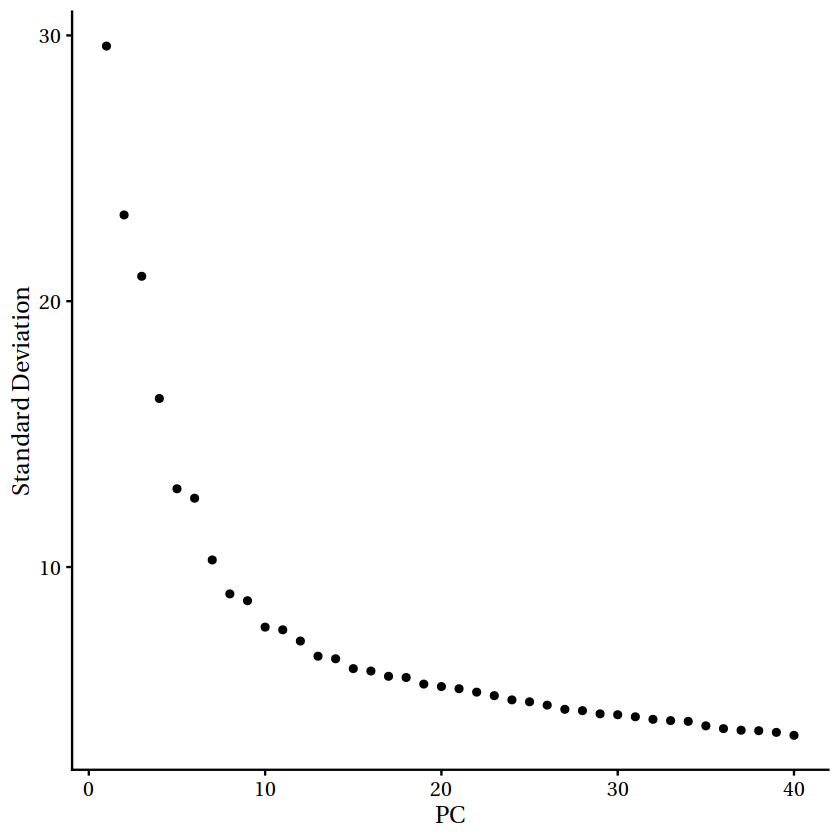

In [7]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


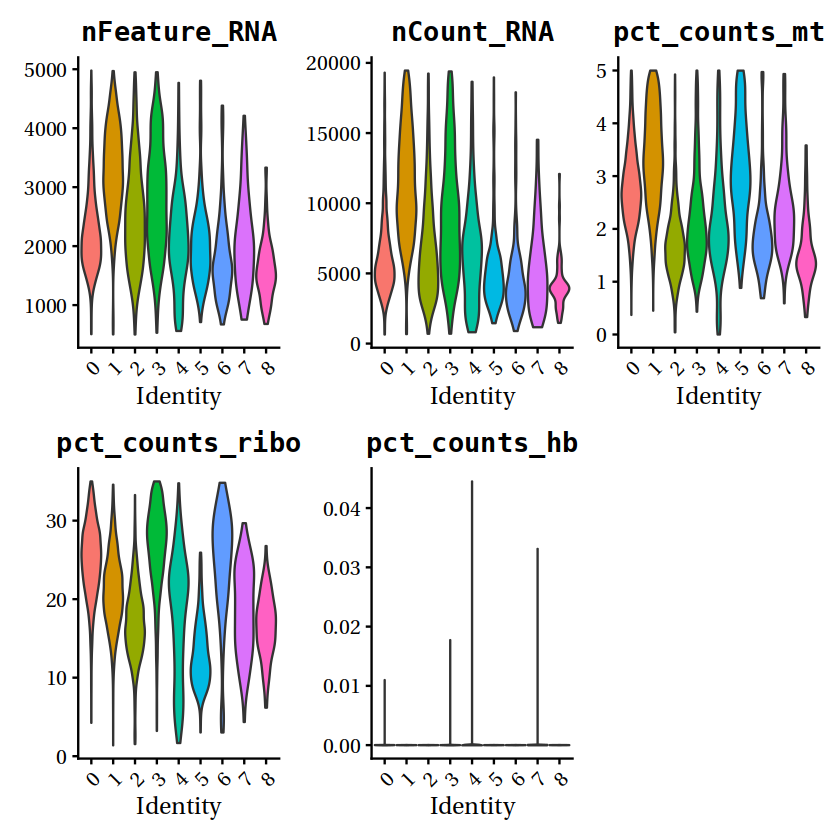

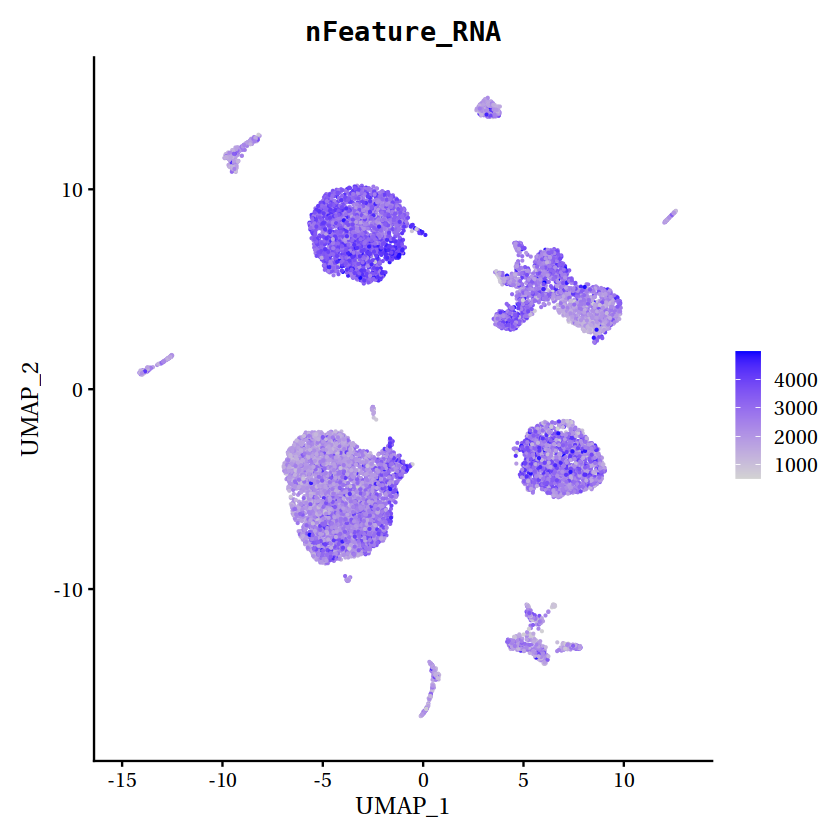

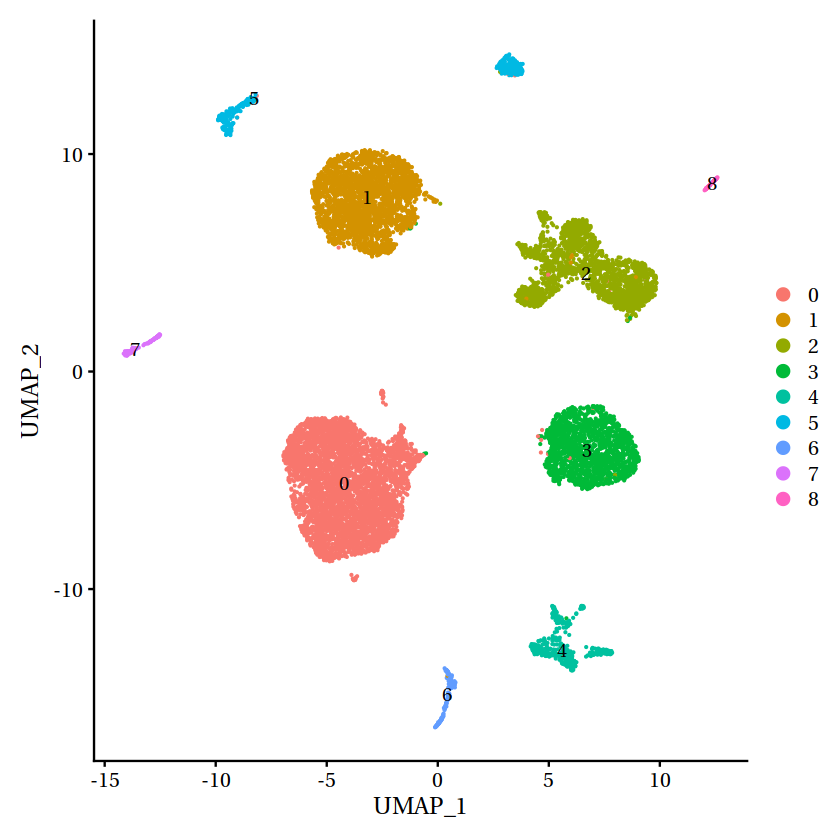

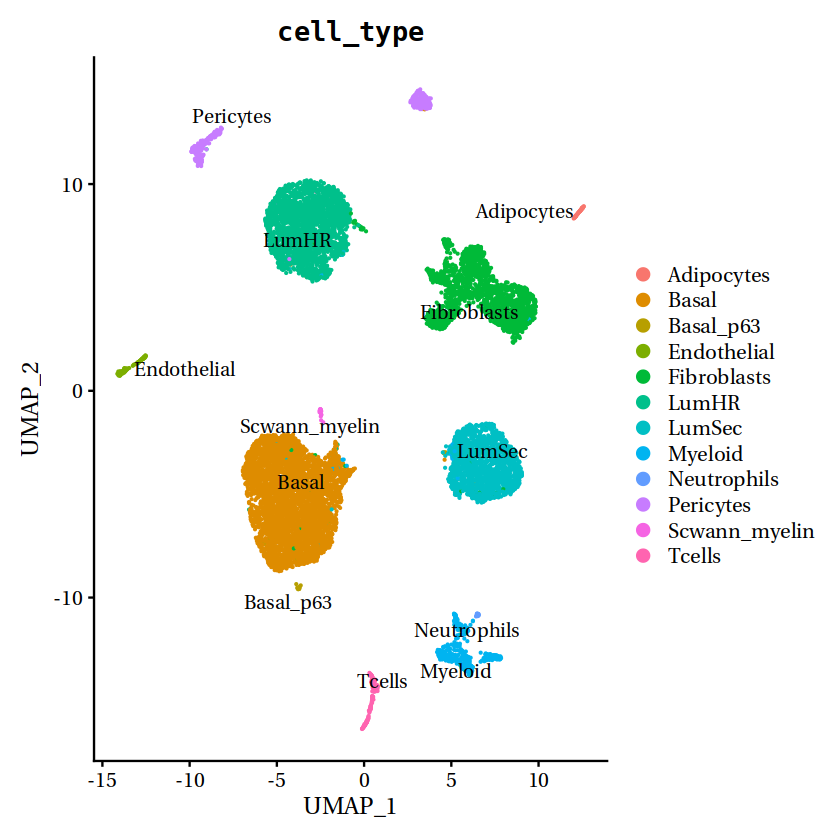

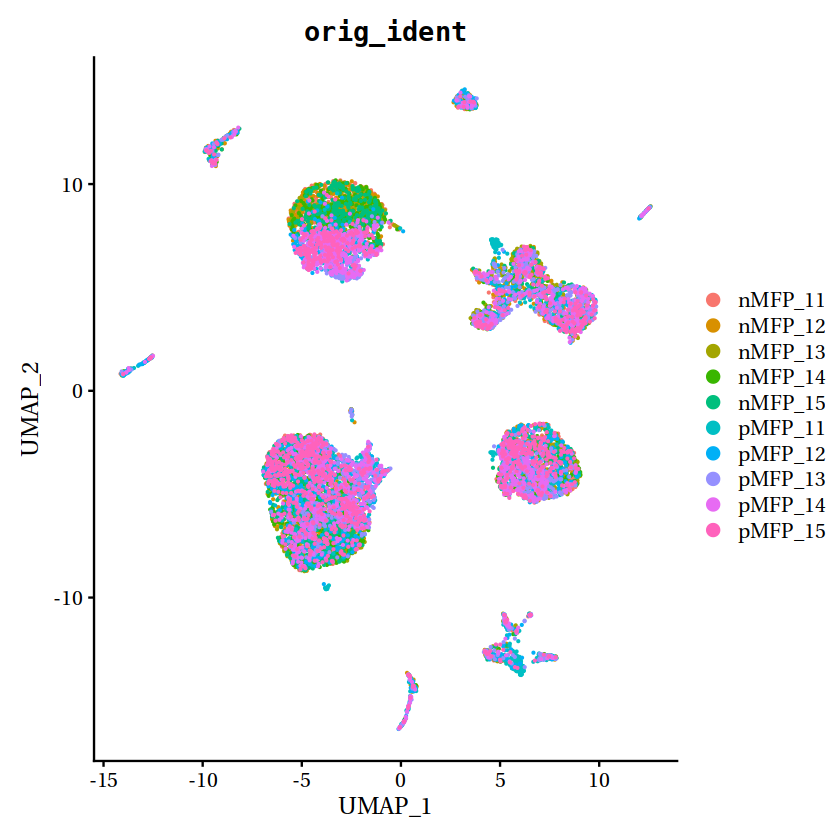

In [8]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

In [13]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA < 750, WhichCells(obj, ident = 0), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 1500, WhichCells(obj, ident = 1), invert = TRUE)

obj <- subset(obj, subset = nFeature_RNA > 3500, WhichCells(obj, ident = c(5,6)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4500, WhichCells(obj, ident = c(0,4)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 3000, WhichCells(obj, ident = 8), invert = TRUE)

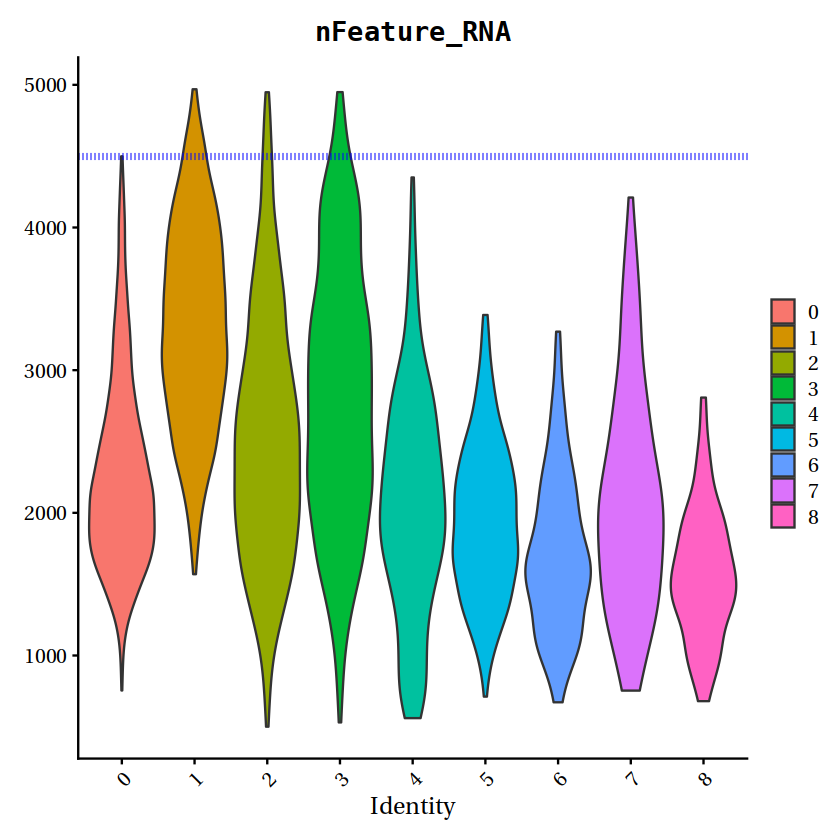

In [14]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 4500, linetype="dotted", 
                color = "blue", size=1.5)

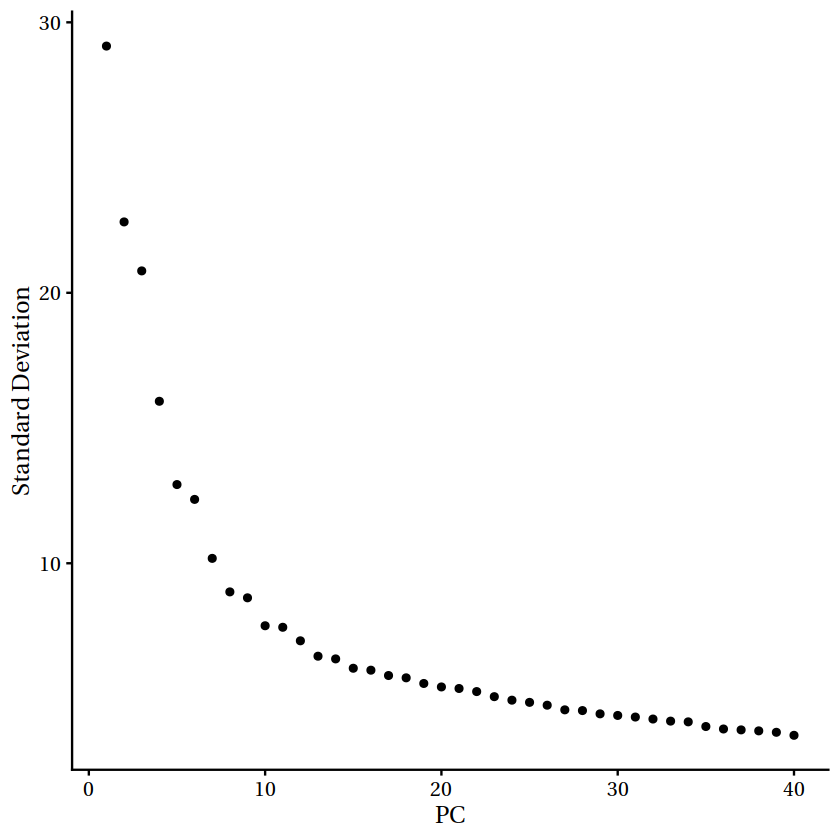

In [15]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

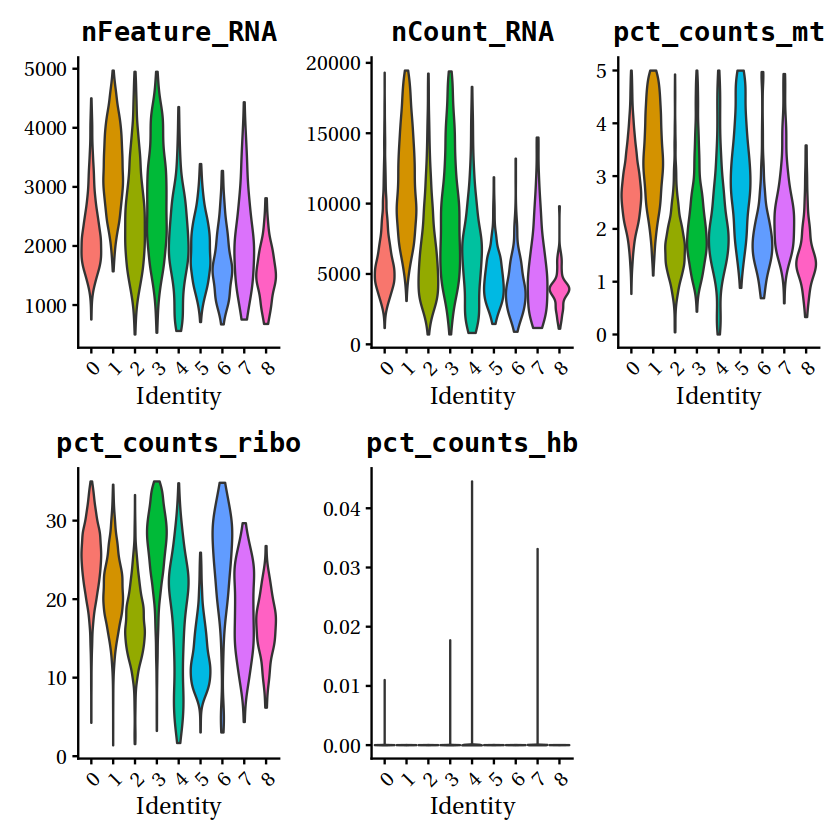

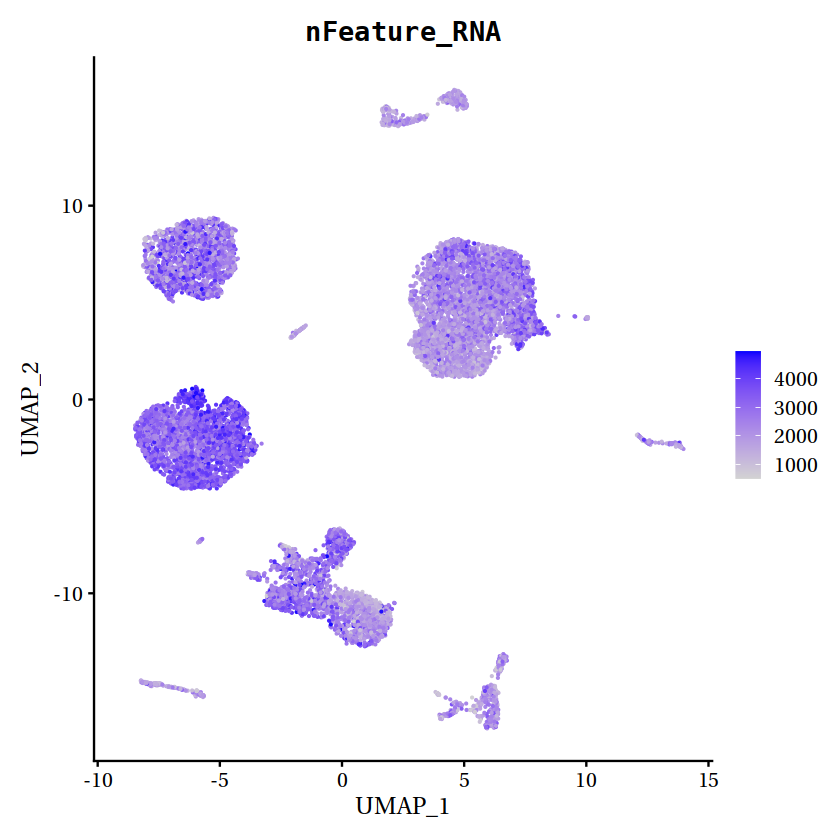

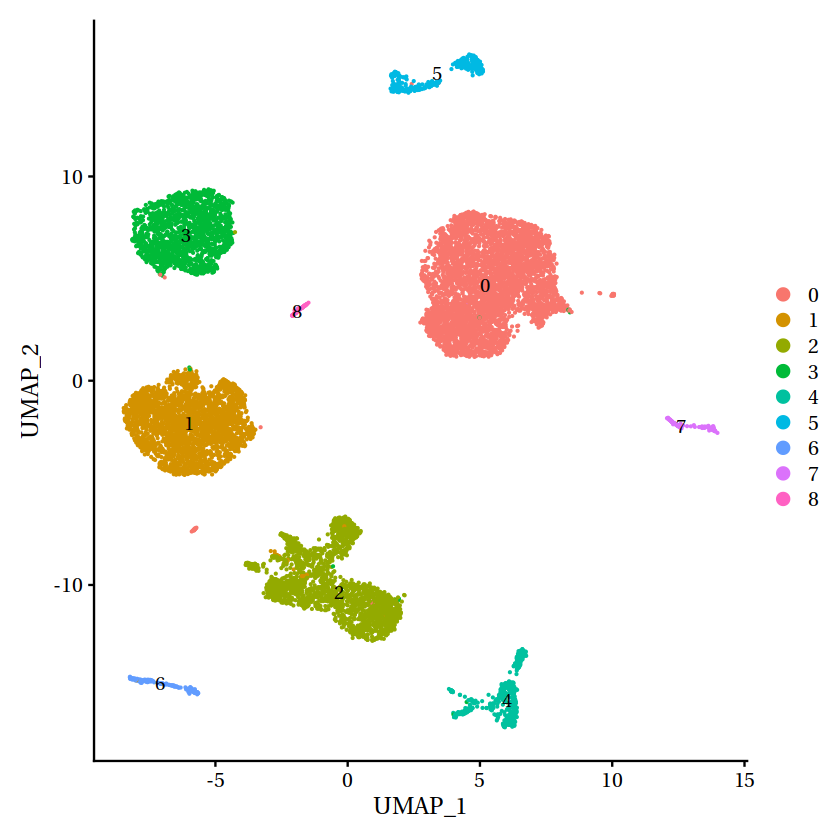

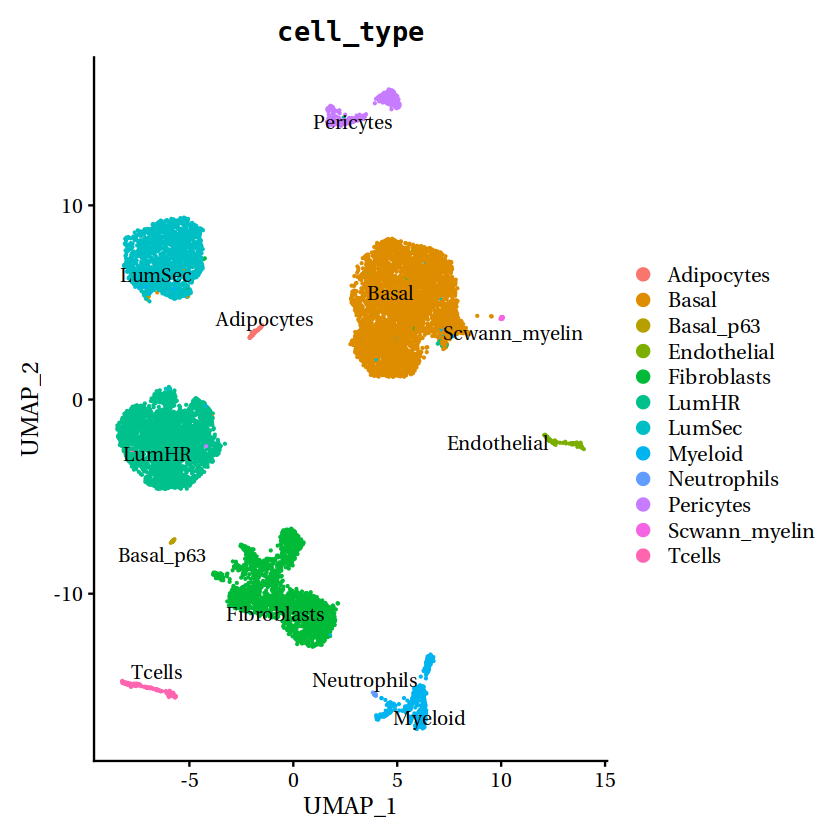

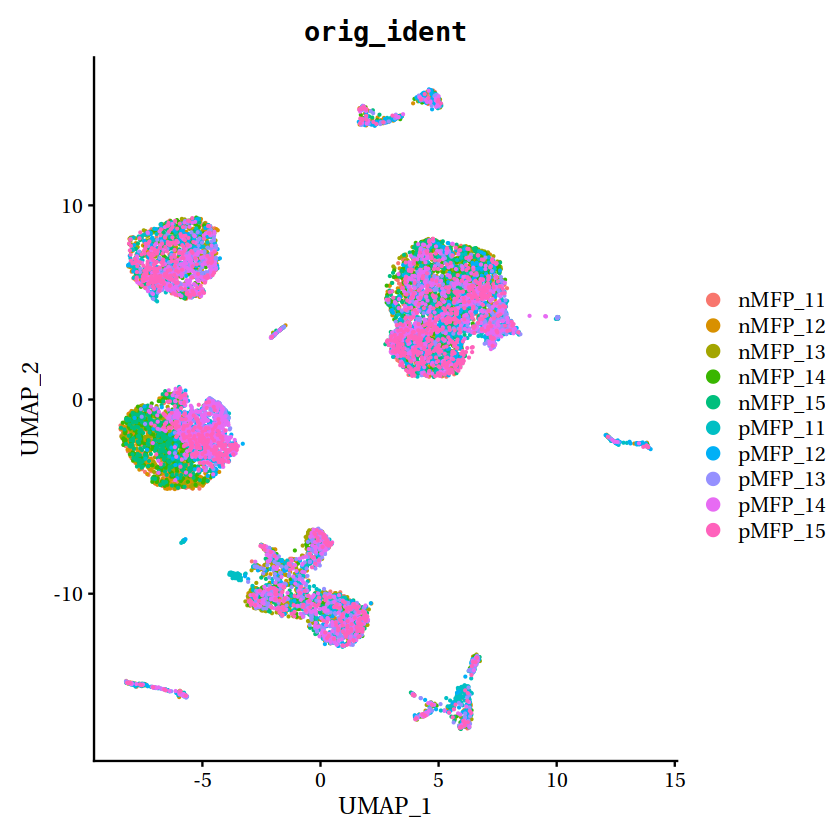

In [16]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

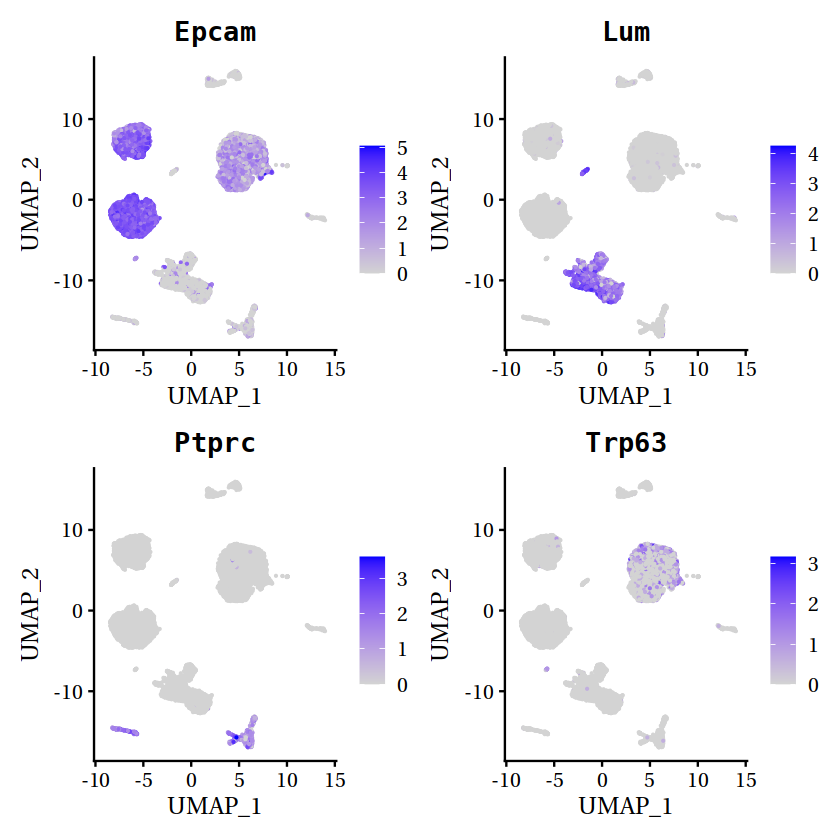

In [17]:
FeaturePlot(obj, c("Epcam","Lum","Ptprc","Trp63"))

In [18]:
saveRDS(obj, "cellplex5_soupX.rds")

# after doublet prediction, CNV

In [19]:
obj <- readRDS("cellplex5_soupX_doubletfinder.rds")

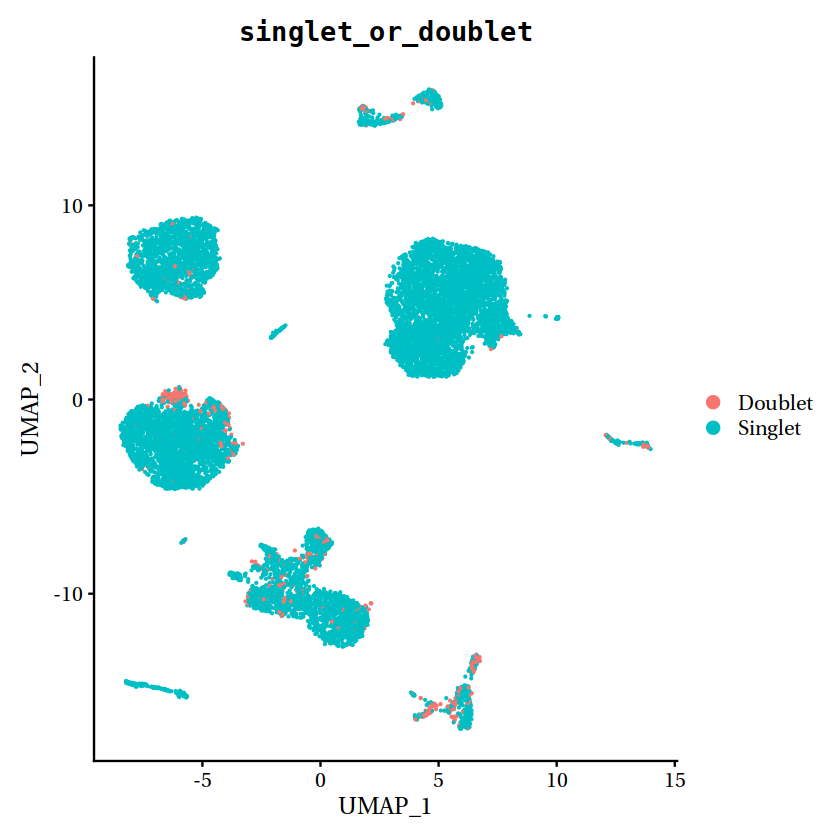

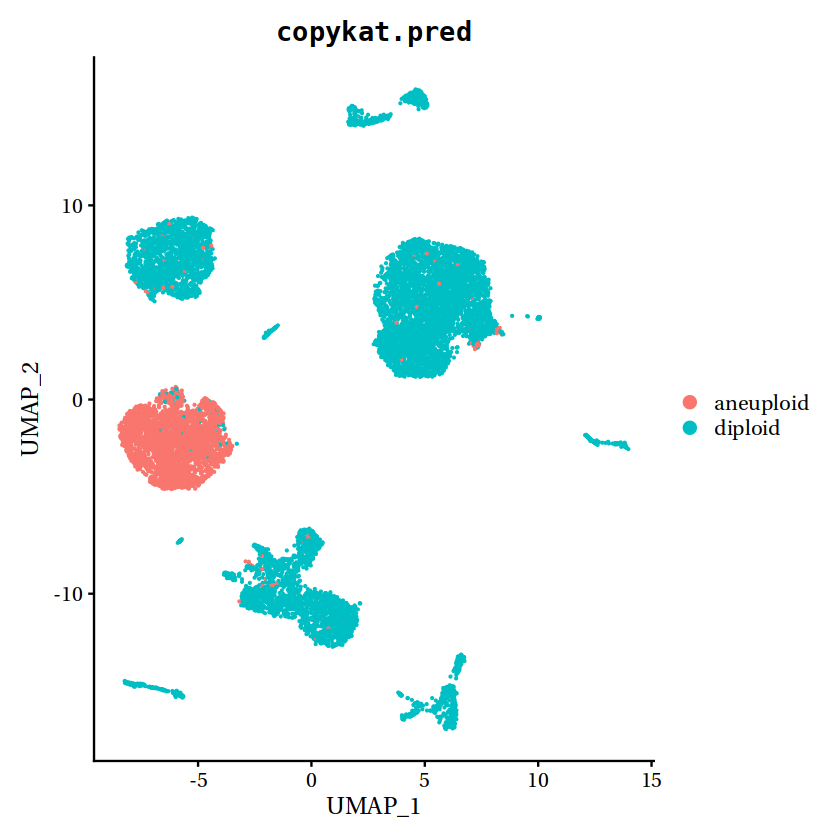

In [20]:
pred <- read.csv("cellplex_5_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

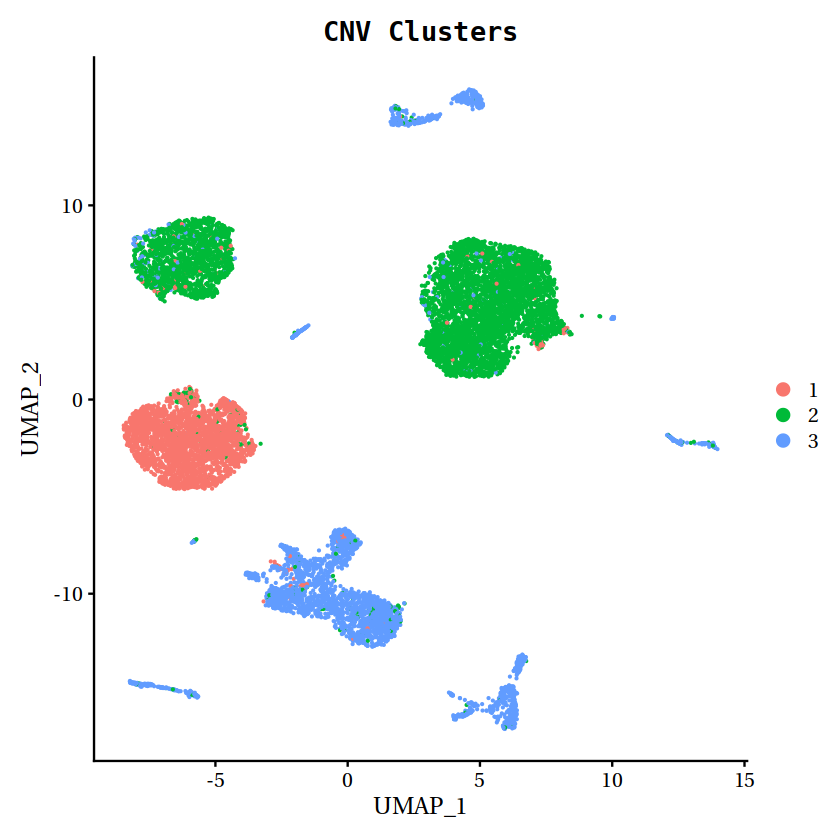

In [22]:
clust_res <- readRDS("cellplex_5_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 3, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

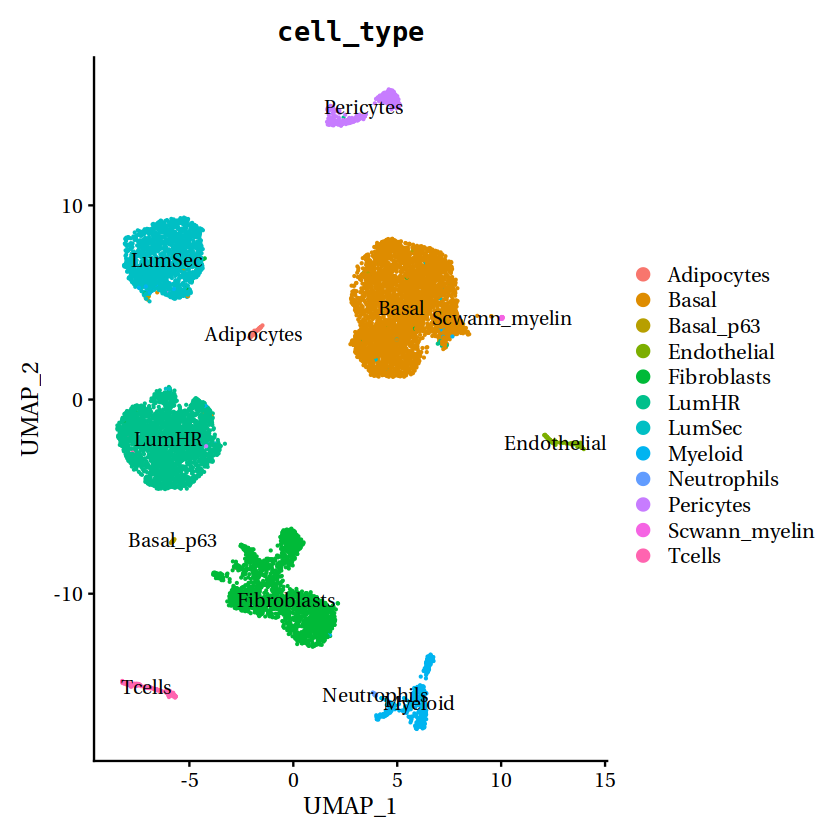

In [23]:
DimPlot(obj, group.by="cell_type", label = T)

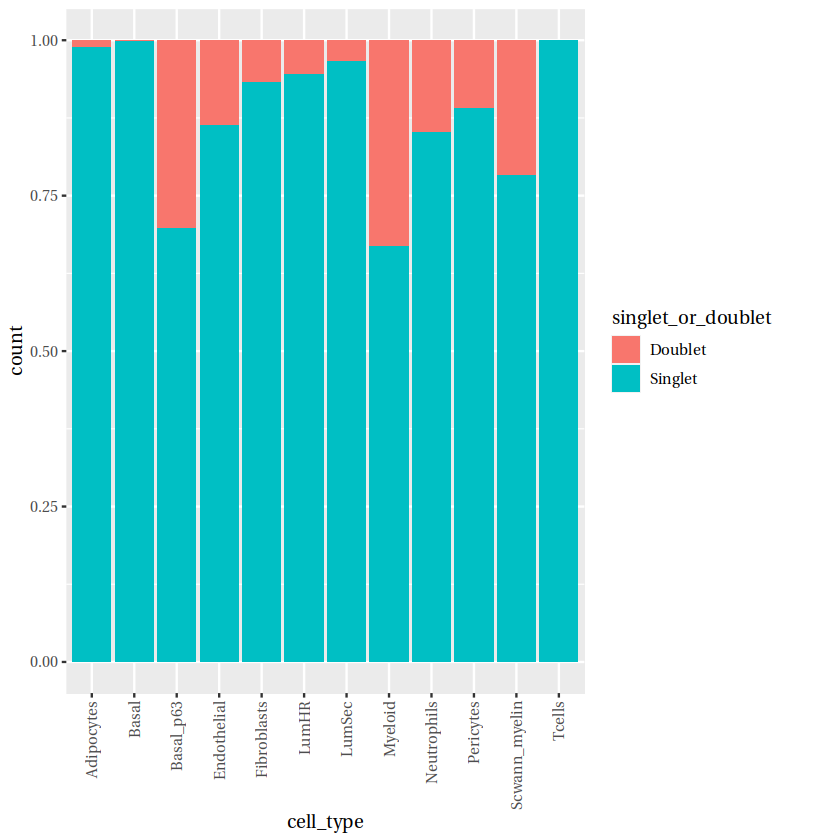

In [25]:
ggplot(obj@meta.data, aes(x=cell_type, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check normal

In [26]:
table(obj$orig_ident)


nMFP_11 nMFP_12 nMFP_13 nMFP_14 nMFP_15 pMFP_11 pMFP_12 pMFP_13 pMFP_14 pMFP_15 
   1216    1294    1374    1219    1253    1215    1051    1272    1434    1177 

In [27]:
sub <- subset(obj, subset = orig_ident %in% c("nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15"))

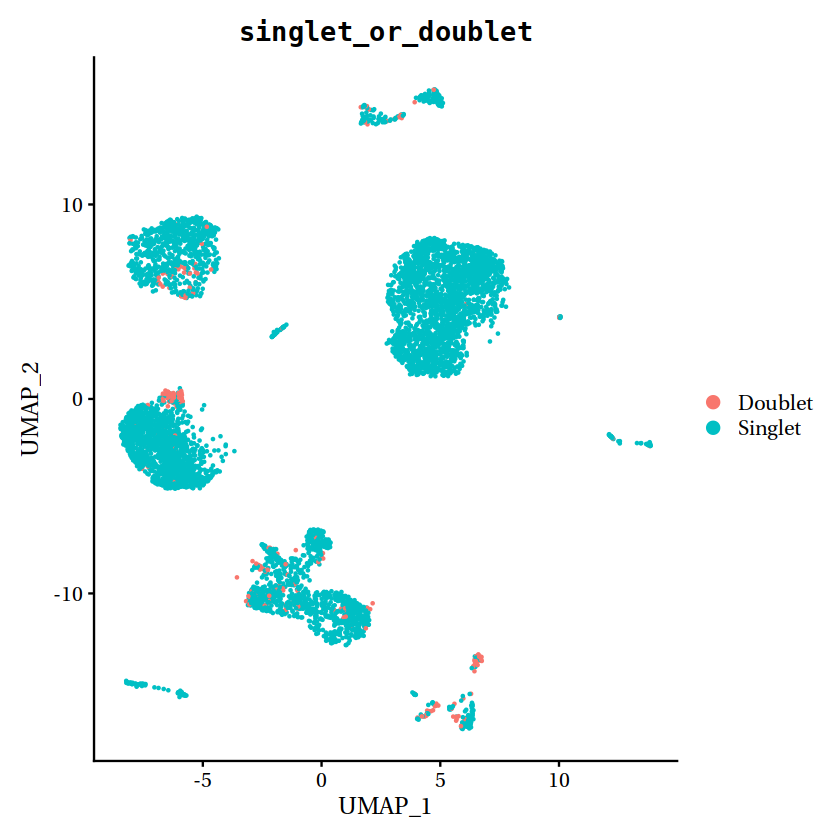

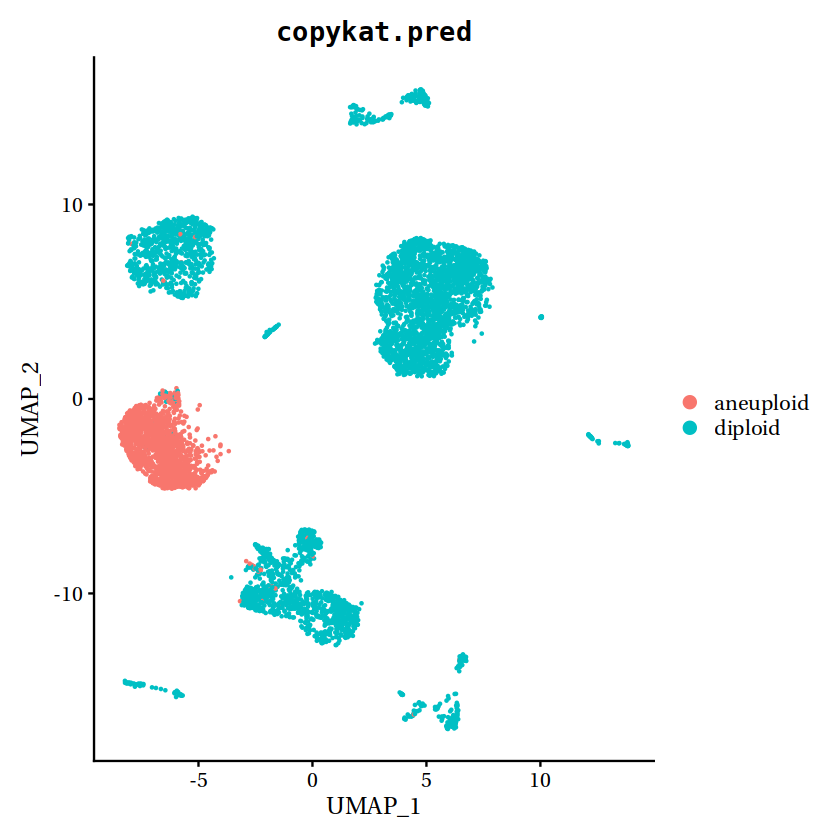

In [28]:
DimPlot(sub, group.by = "singlet_or_doublet")
DimPlot(sub, group.by="copykat.pred")

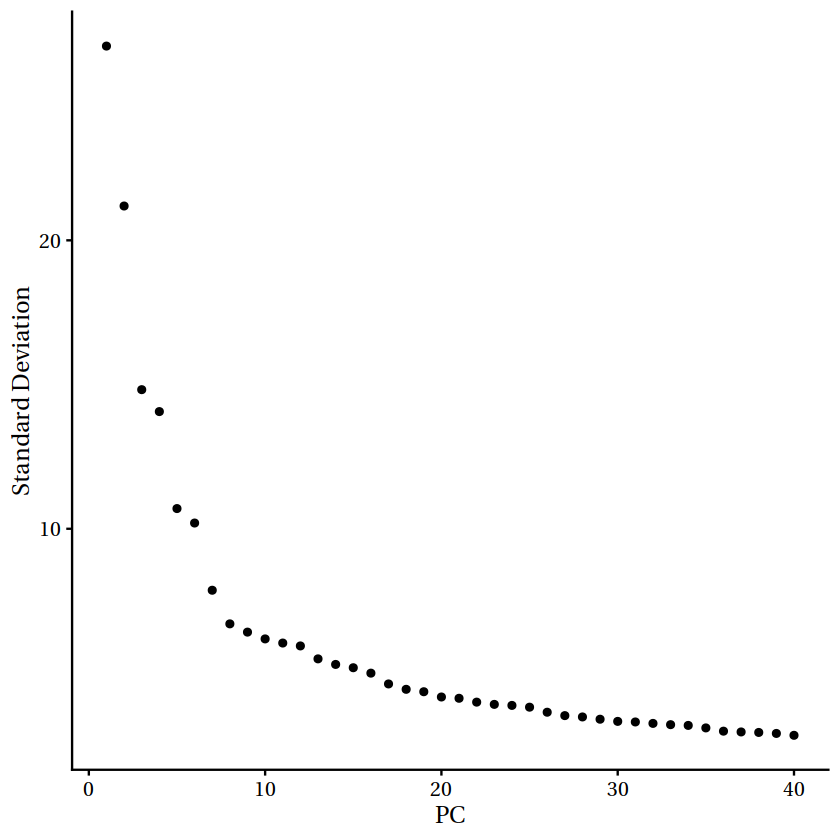

In [29]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

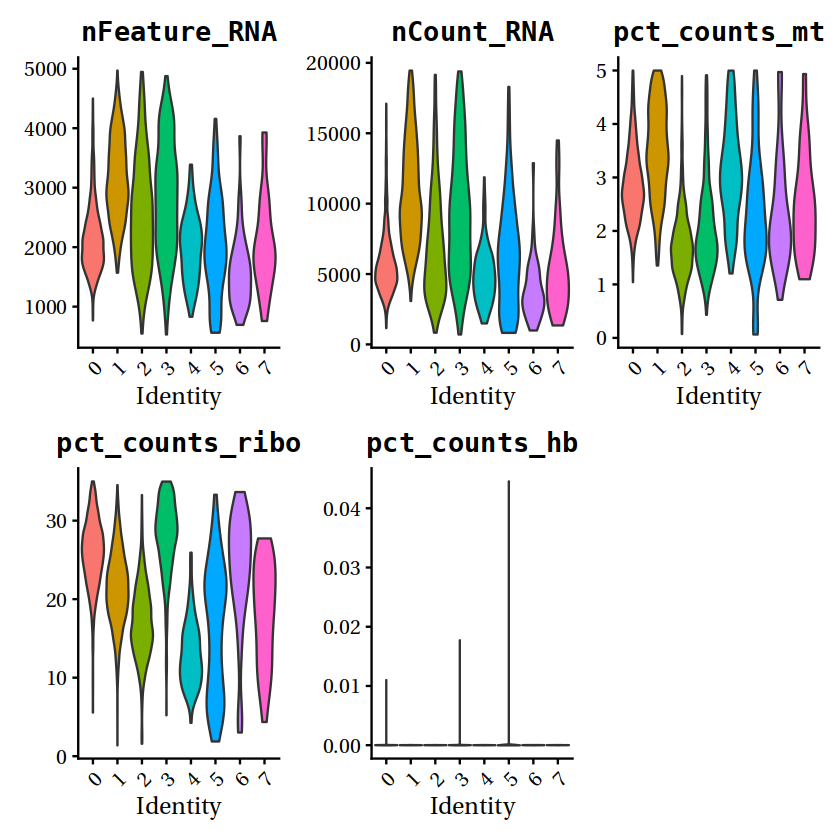

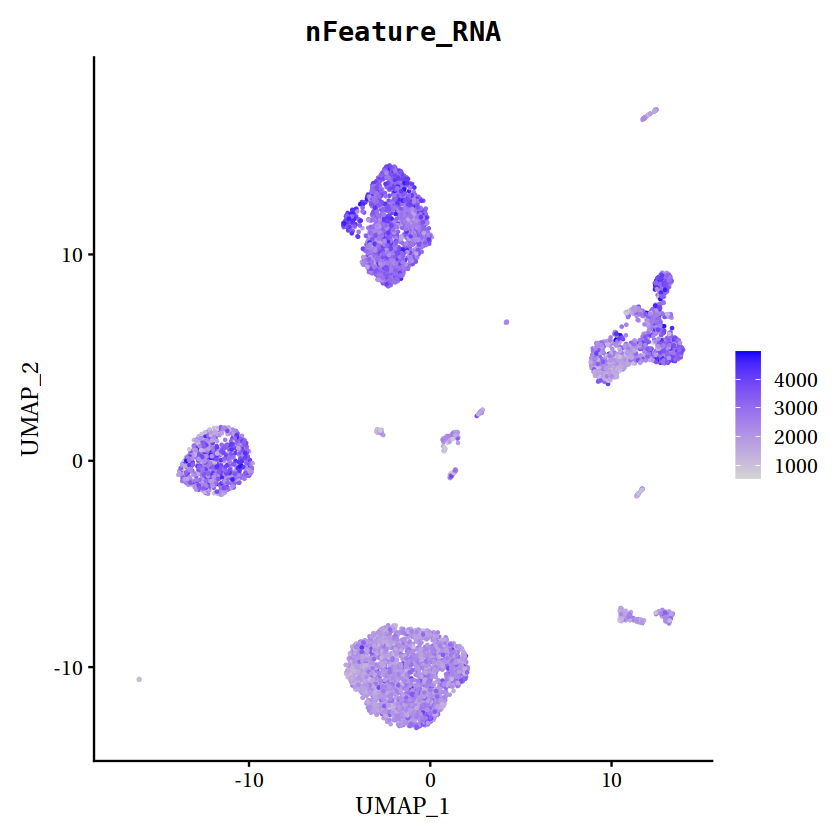

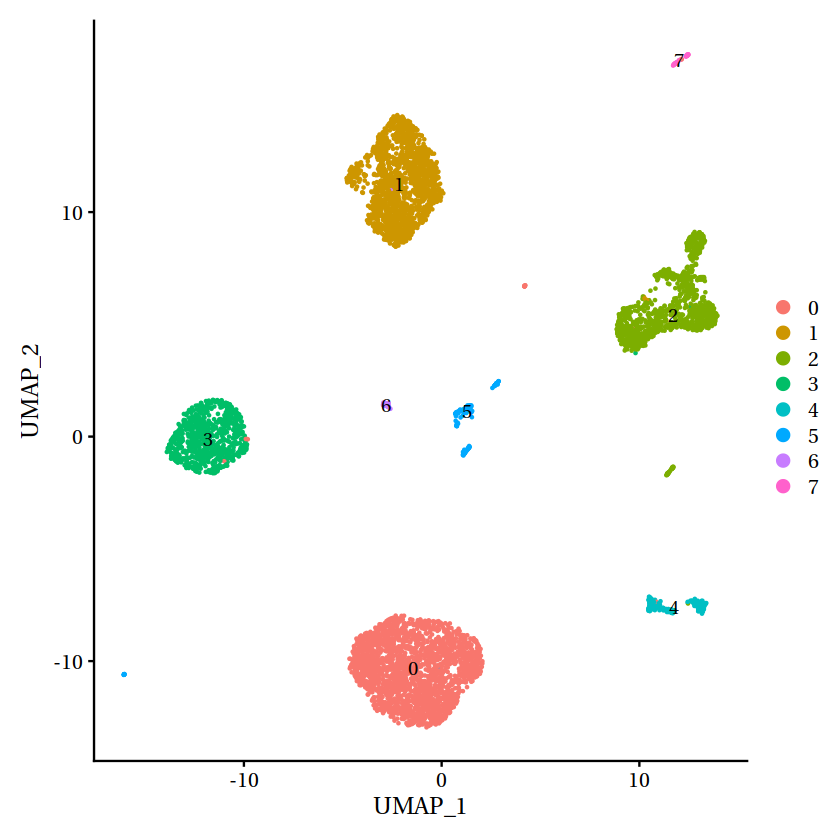

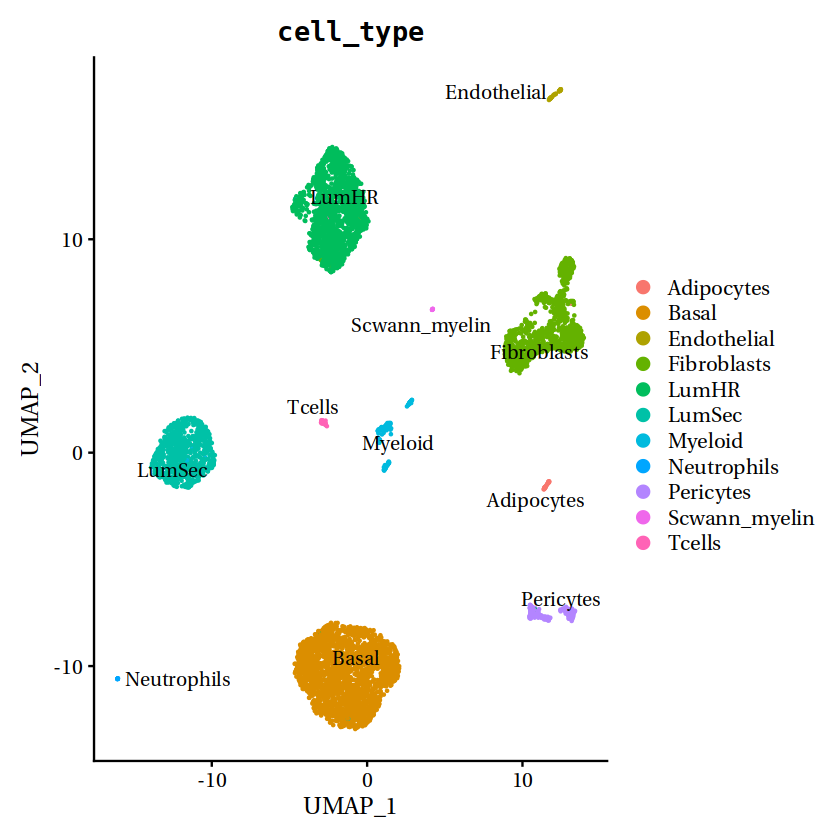

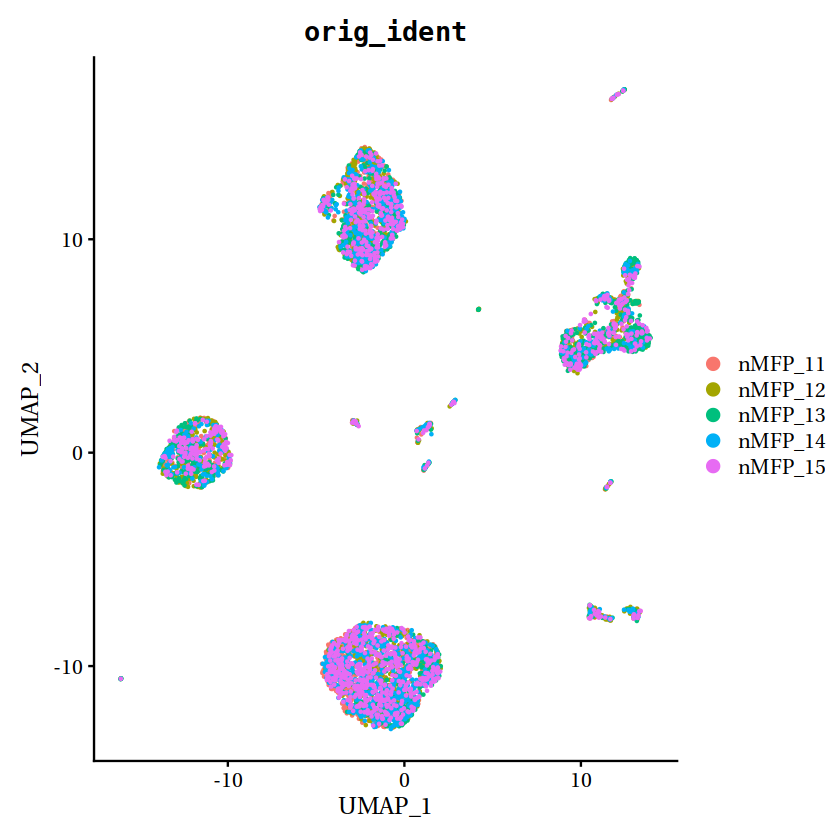

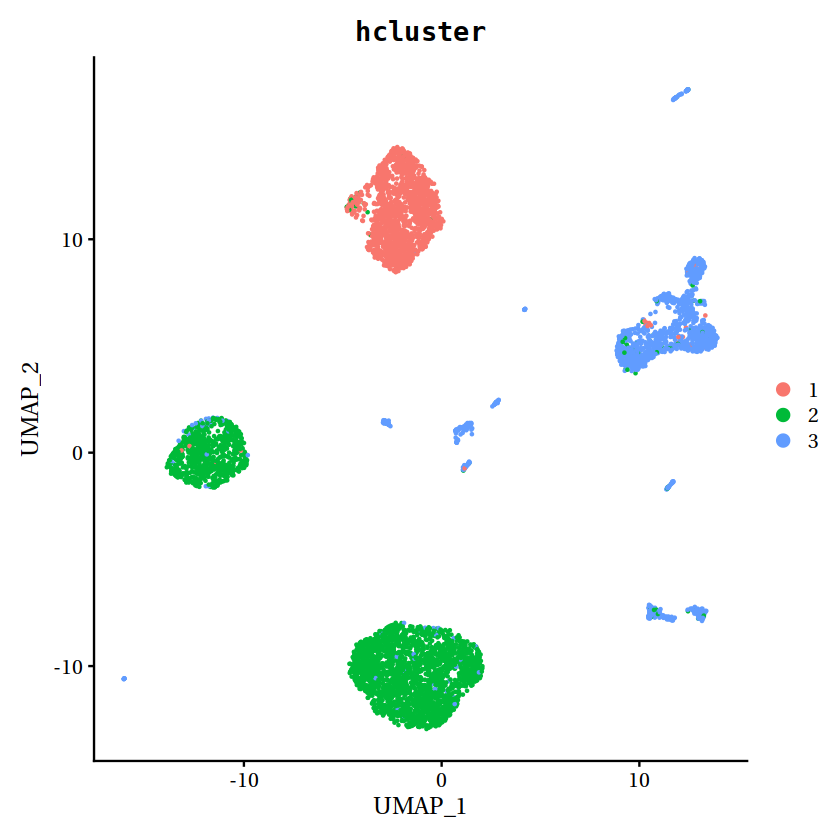

In [30]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "hcluster", label = F)

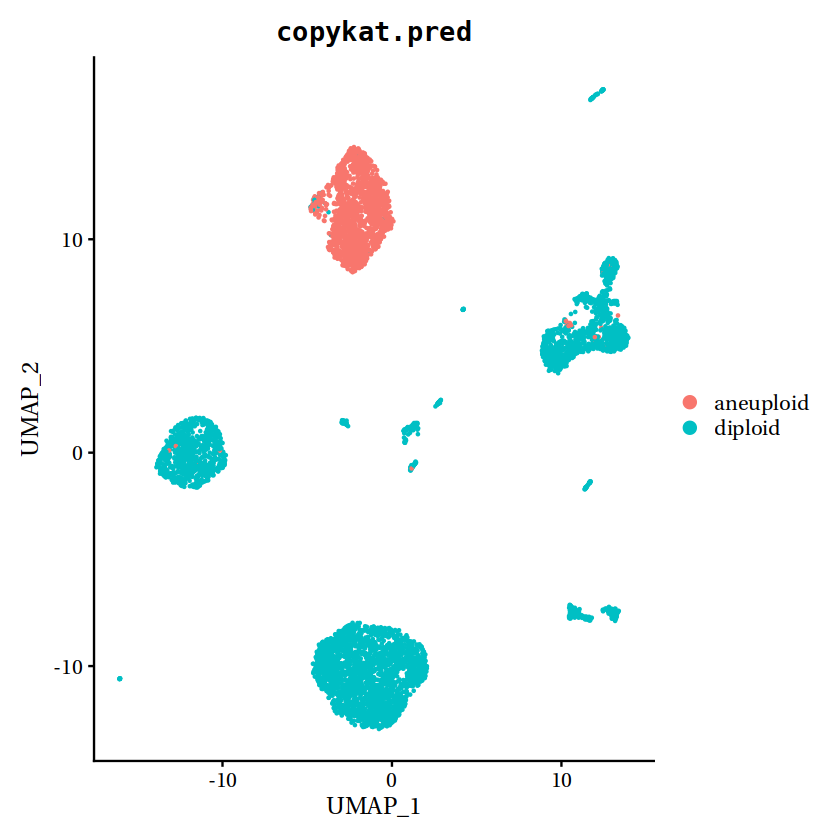

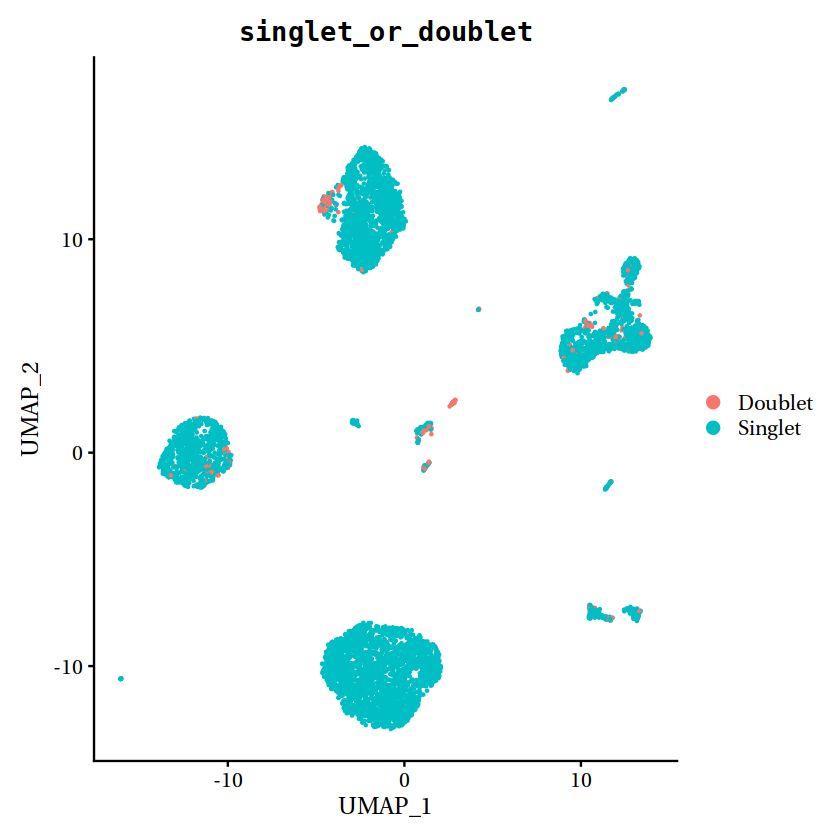

In [31]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")

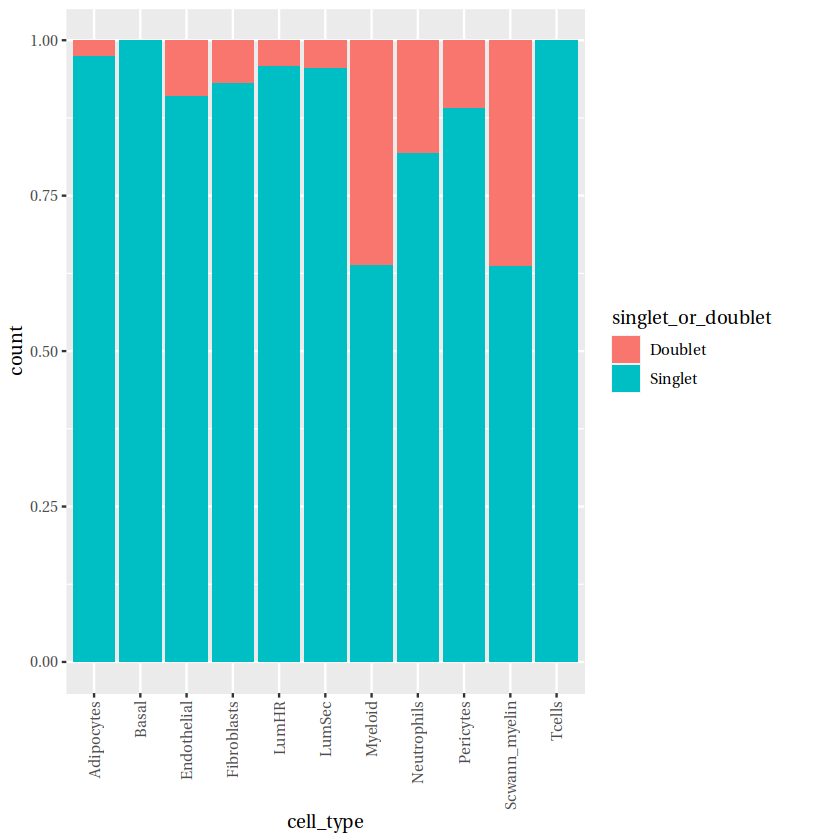

In [32]:
ggplot(sub@meta.data, aes(x=cell_type, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

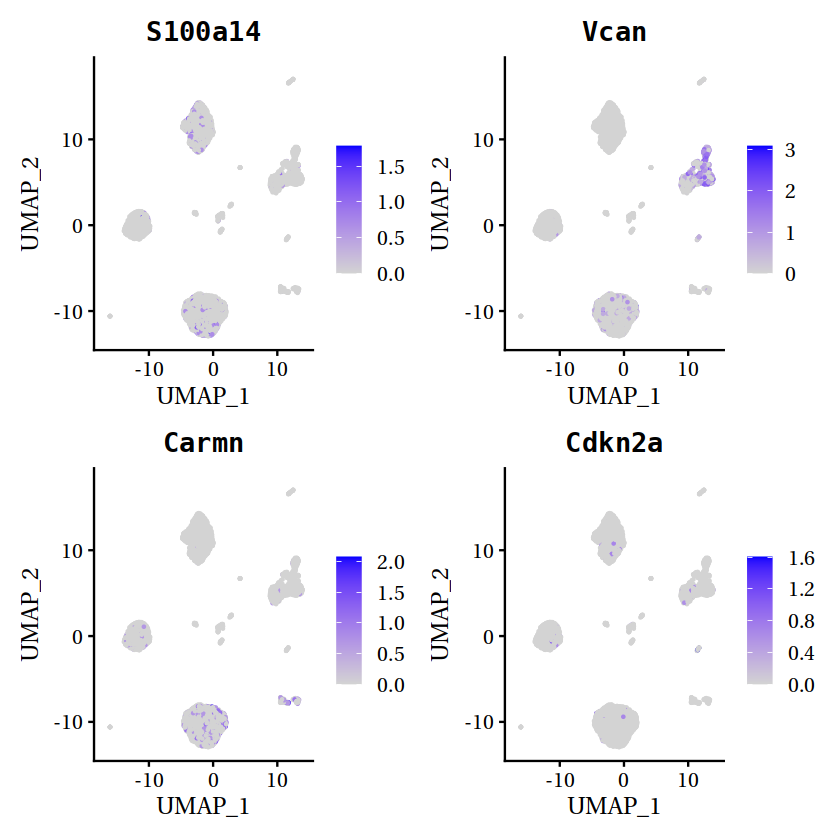

In [33]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"))

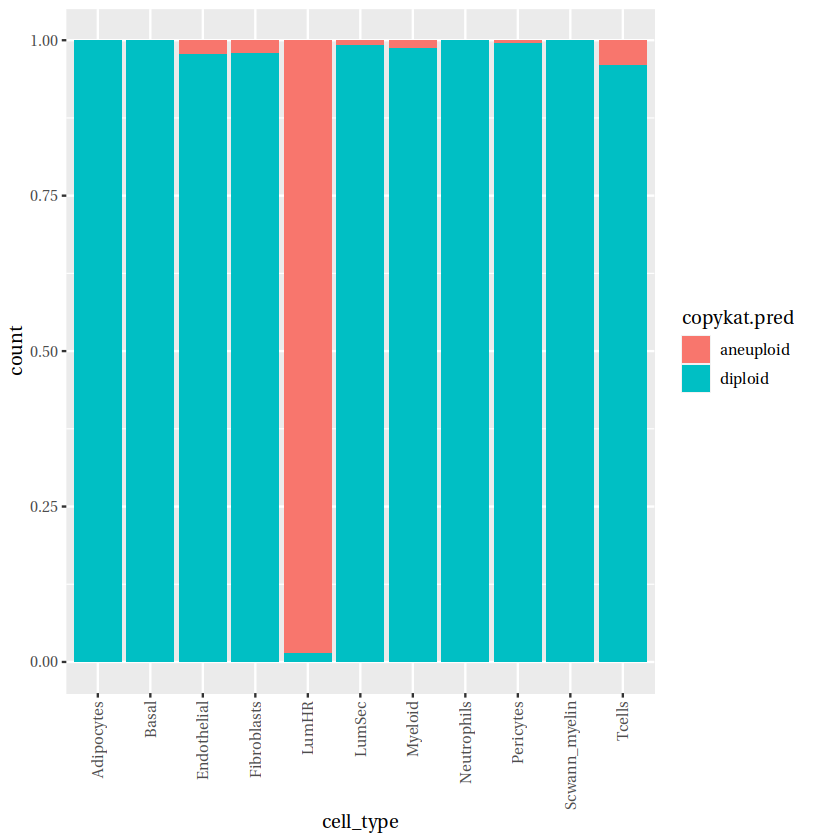

In [34]:
ggplot(sub@meta.data, aes(x=cell_type, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check but don't save premalignant

In [35]:
sub <- subset(obj, subset = orig_ident %in% c("nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15"), invert = T)

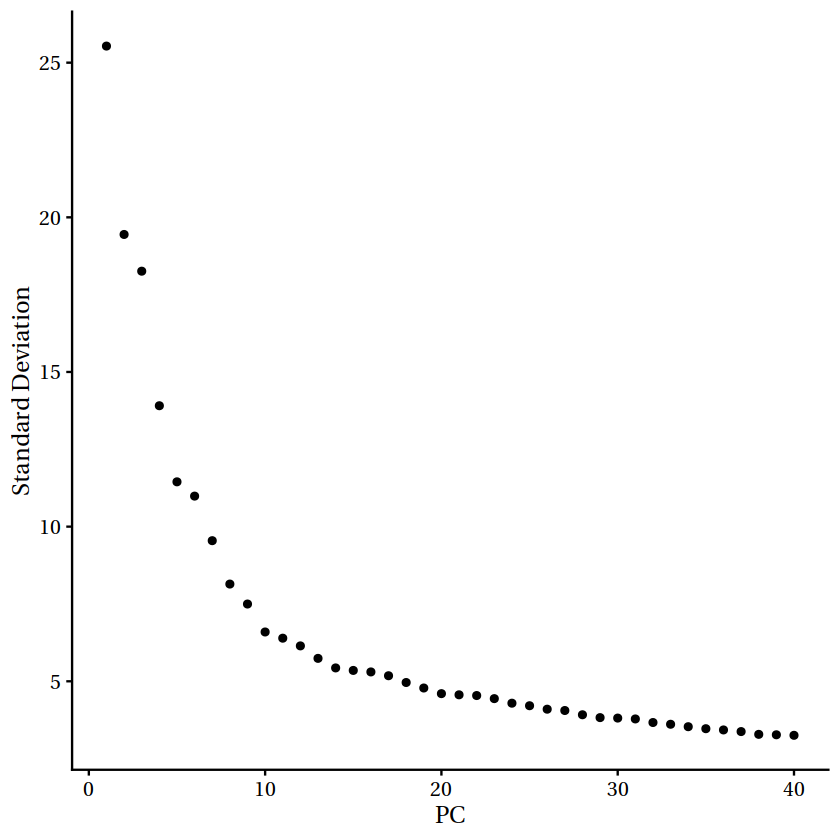

In [36]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

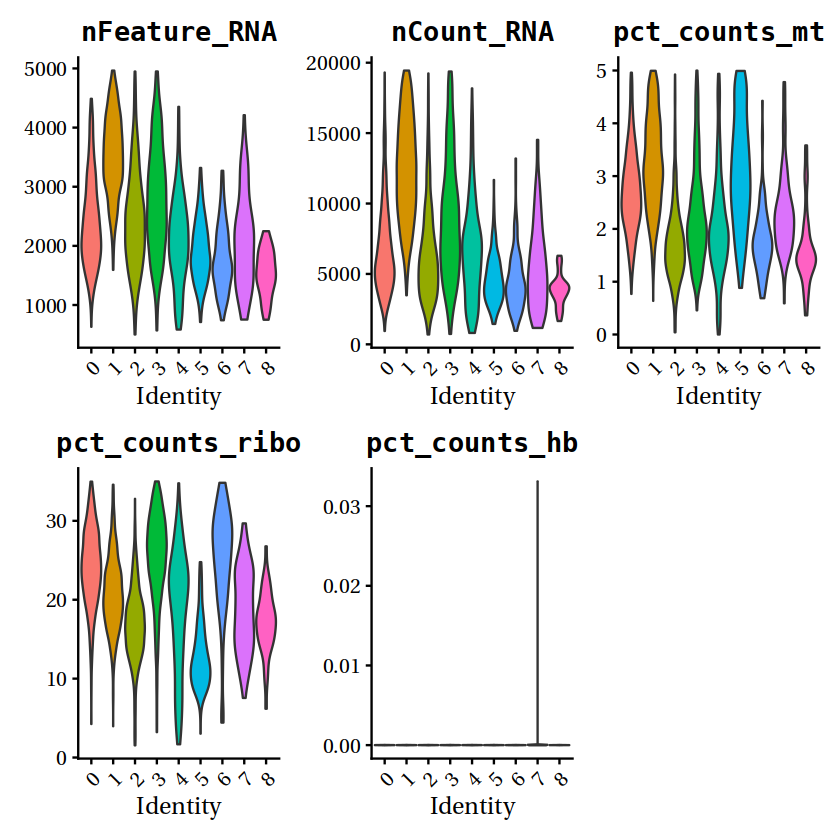

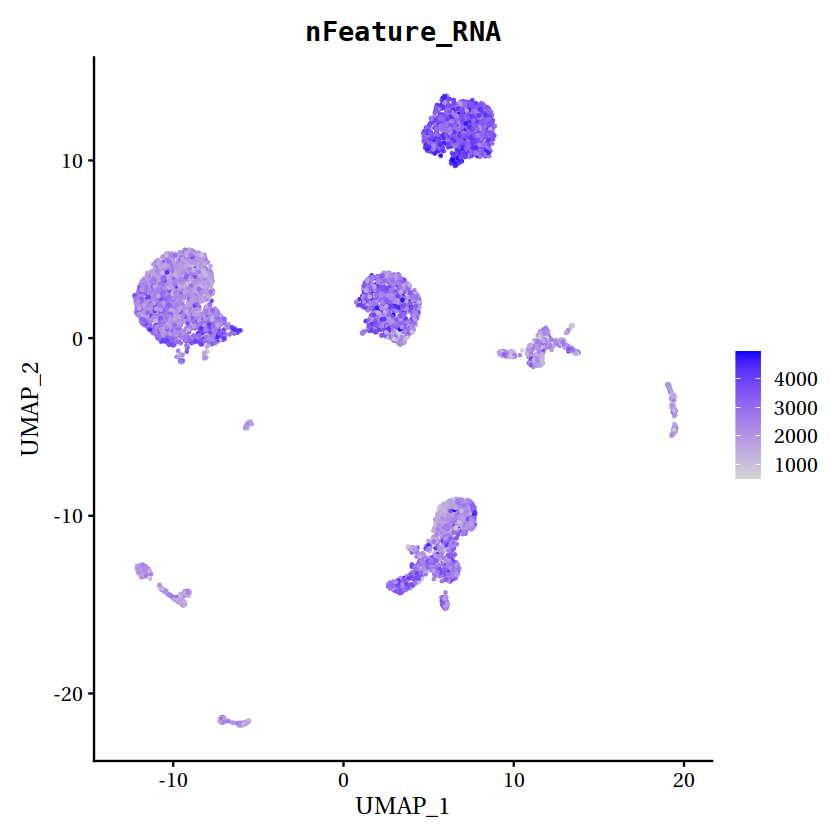

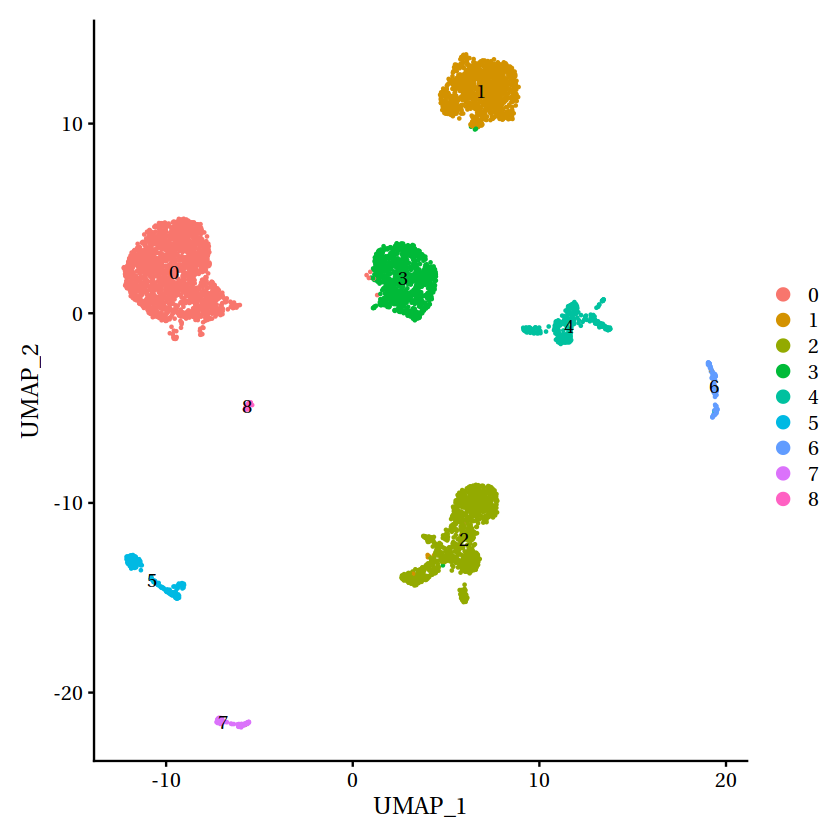

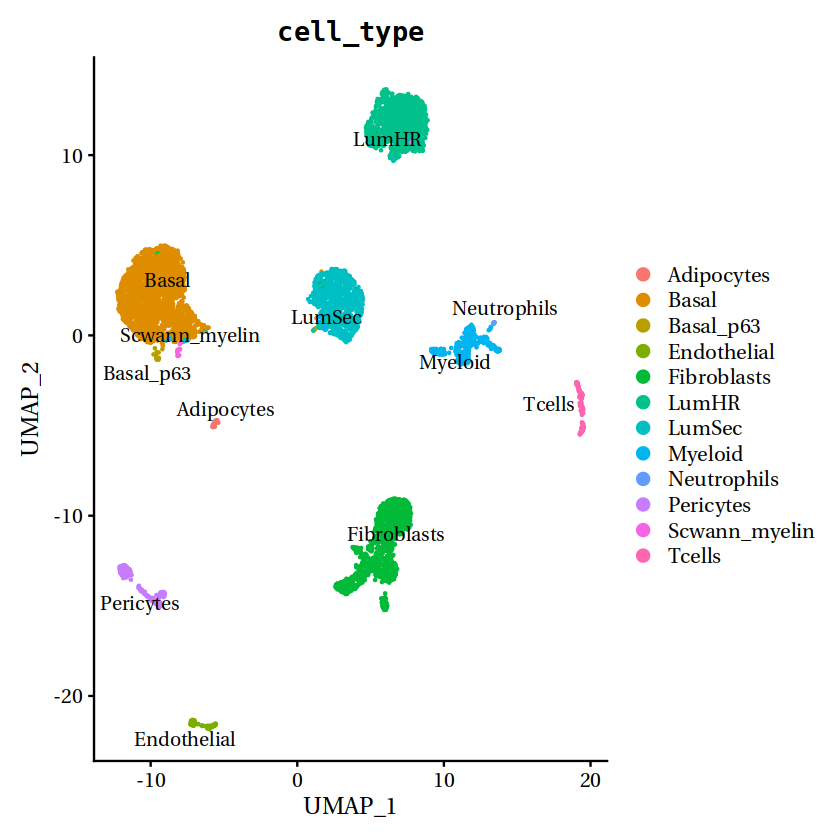

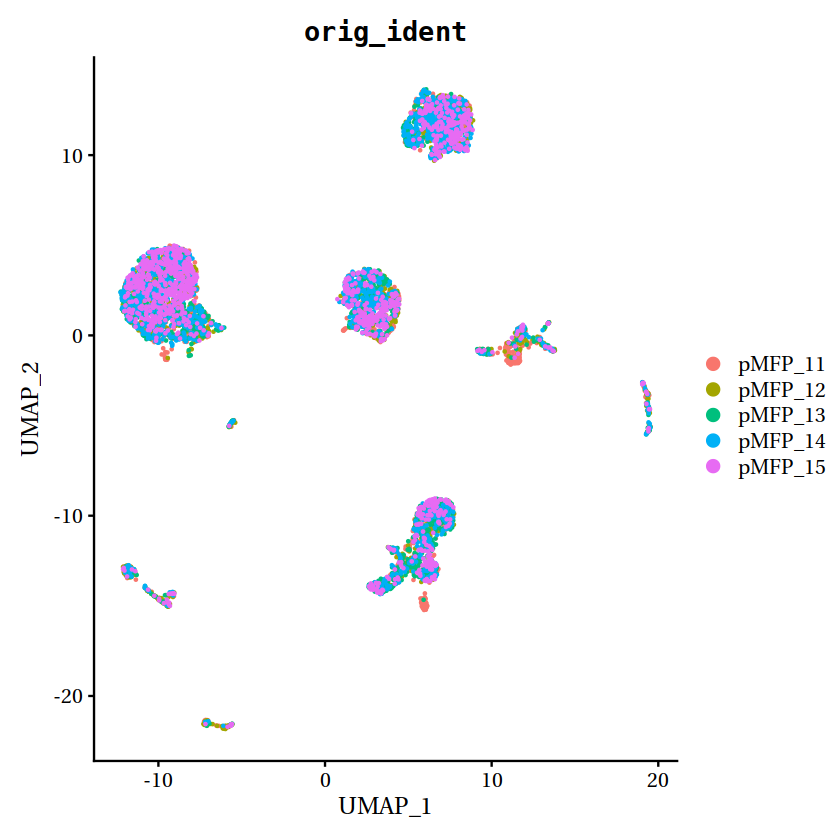

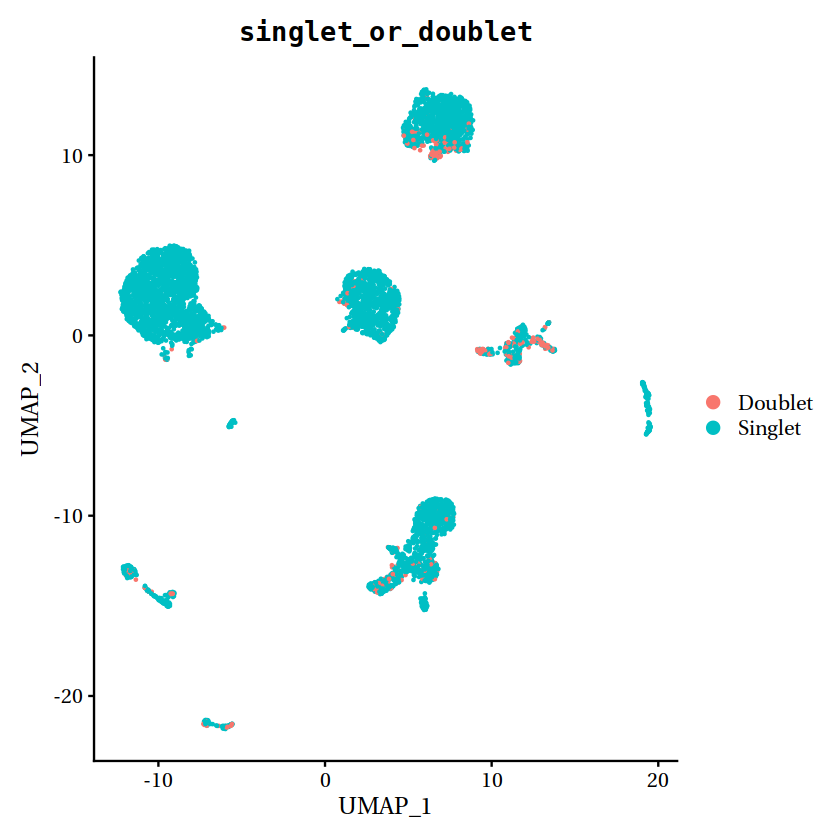

In [37]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

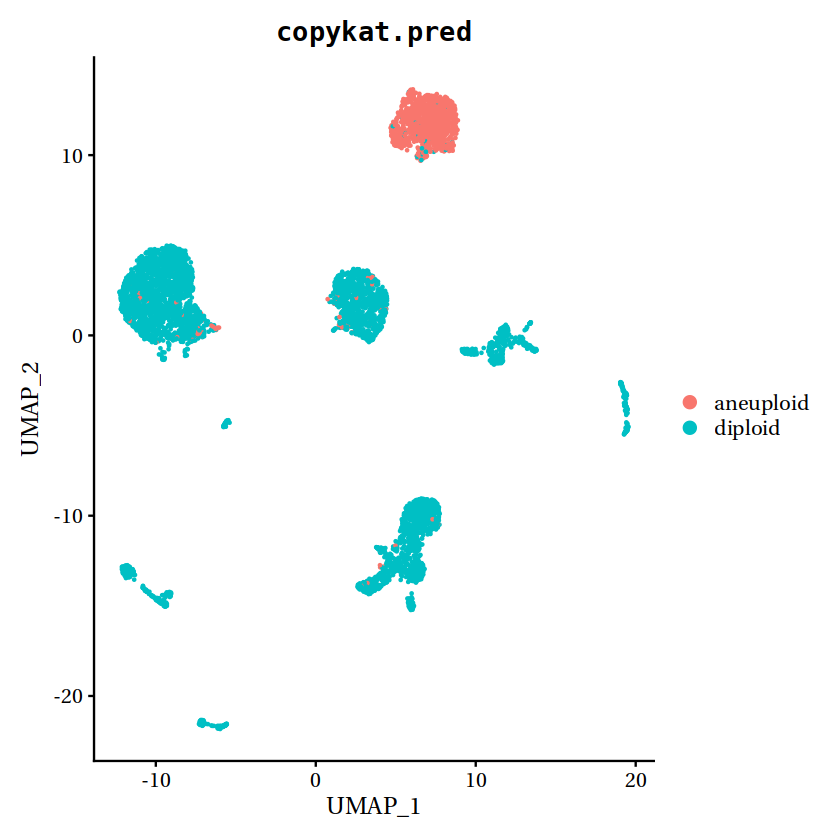

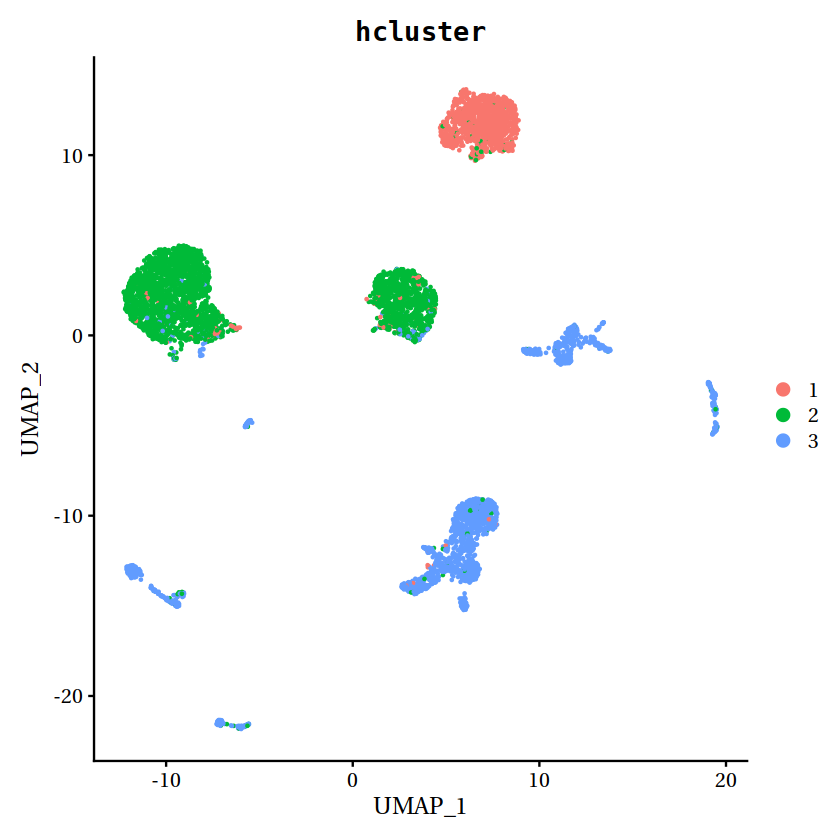

In [38]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="hcluster")

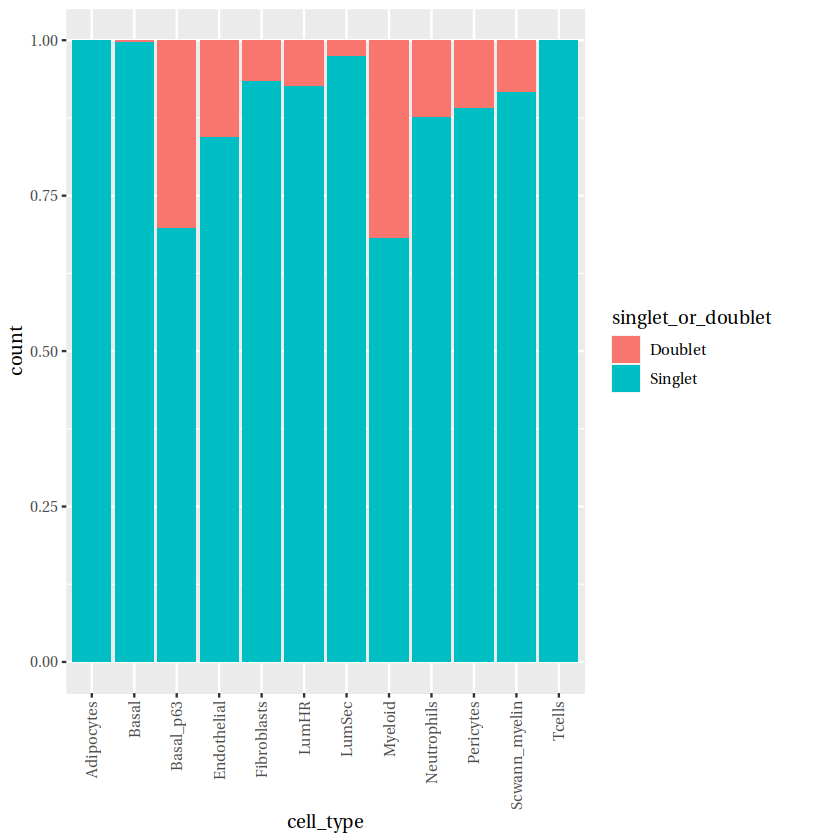

In [39]:
ggplot(sub@meta.data, aes(x=cell_type, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

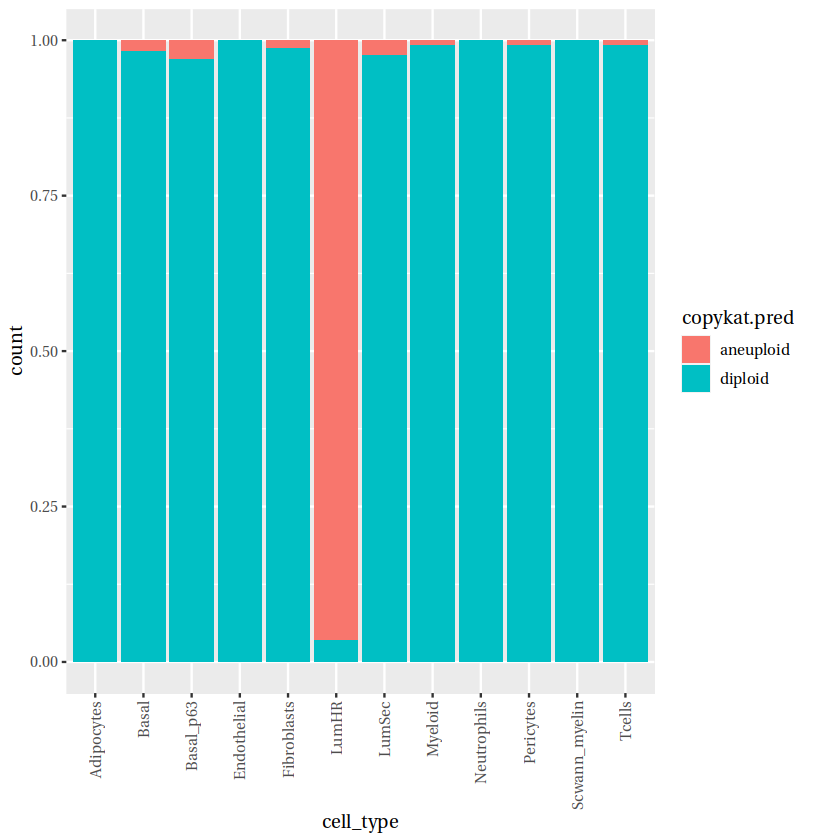

In [40]:
ggplot(sub@meta.data, aes(x=cell_type, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

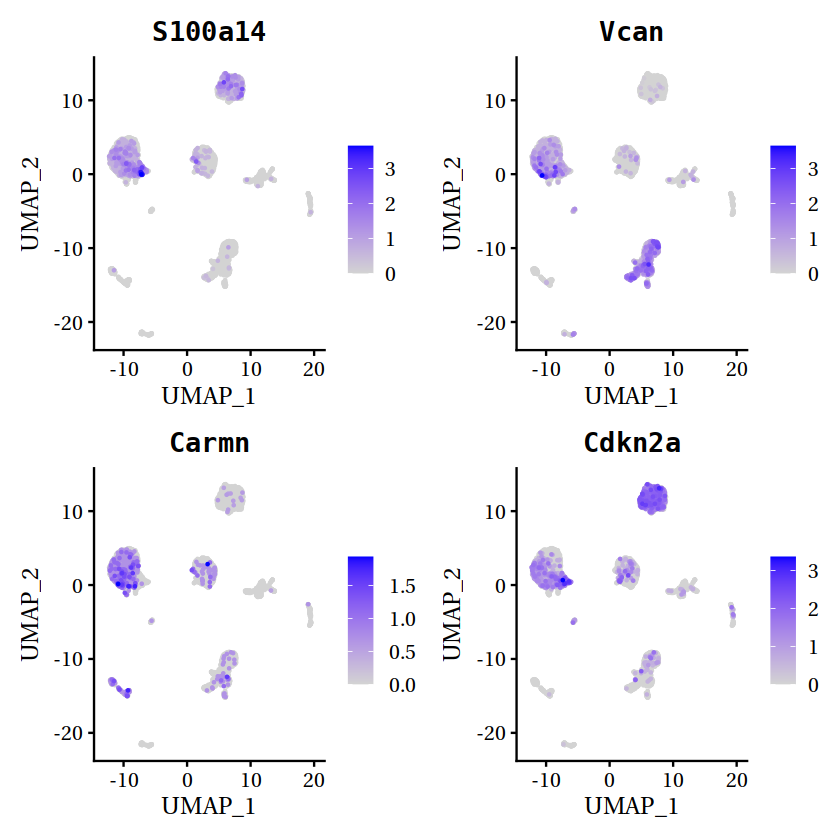

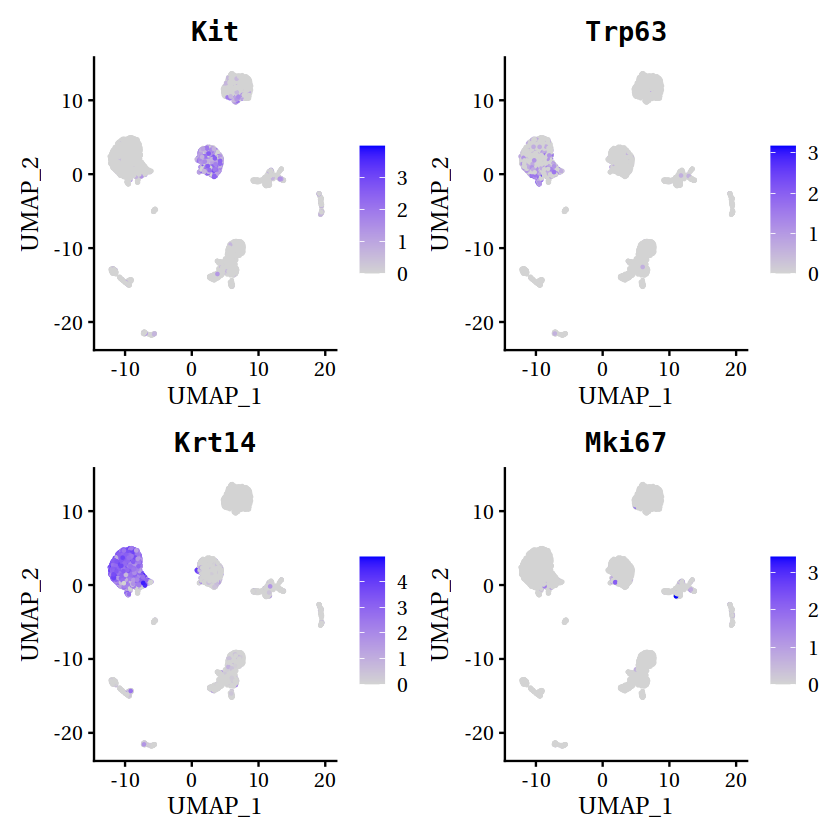

In [41]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)
FeaturePlot(sub, c("Kit","Trp63","Krt14","Mki67"))

## clean up (remove tails)

In [42]:
Idents(obj) <- "seurat_clusters"

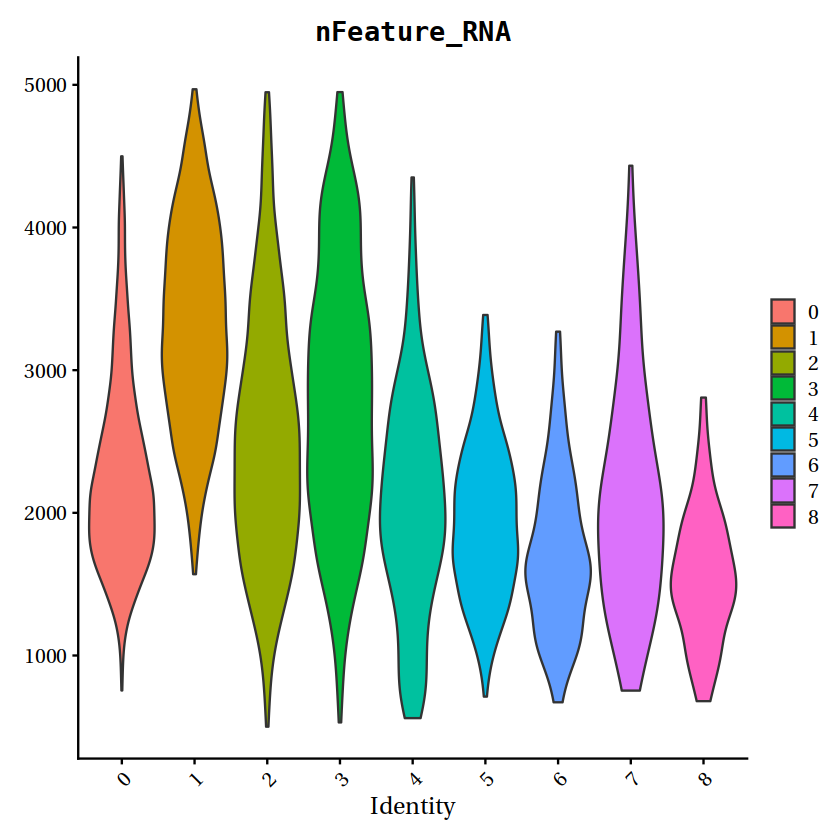

In [43]:
VlnPlot(obj, "nFeature_RNA", pt.size = 0)

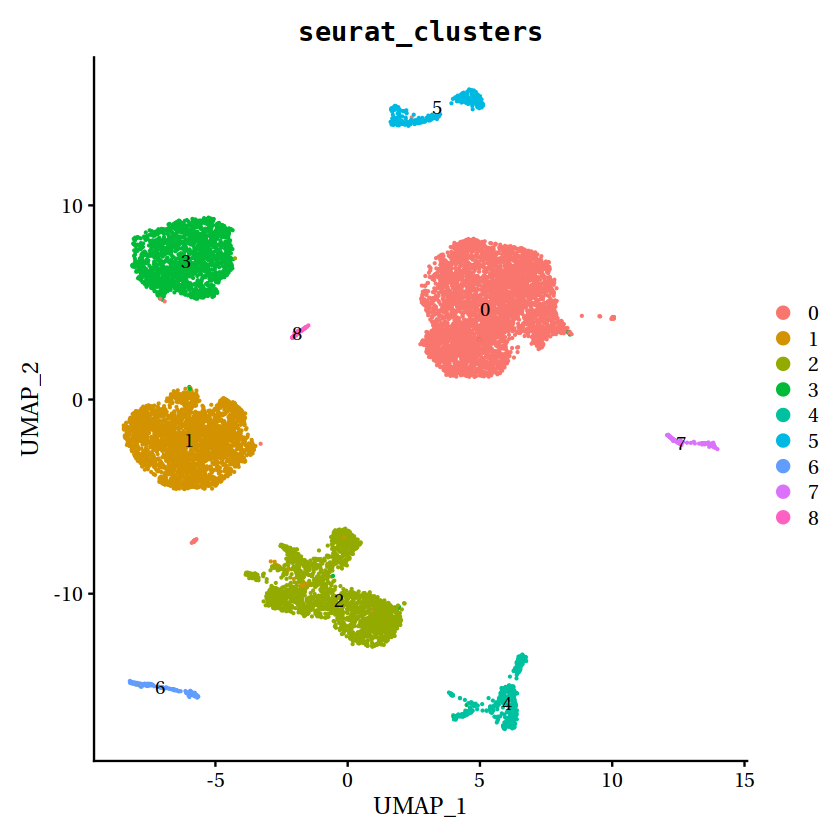

In [44]:
DimPlot(obj, group.by = "seurat_clusters", label = T)

### add important metadata

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

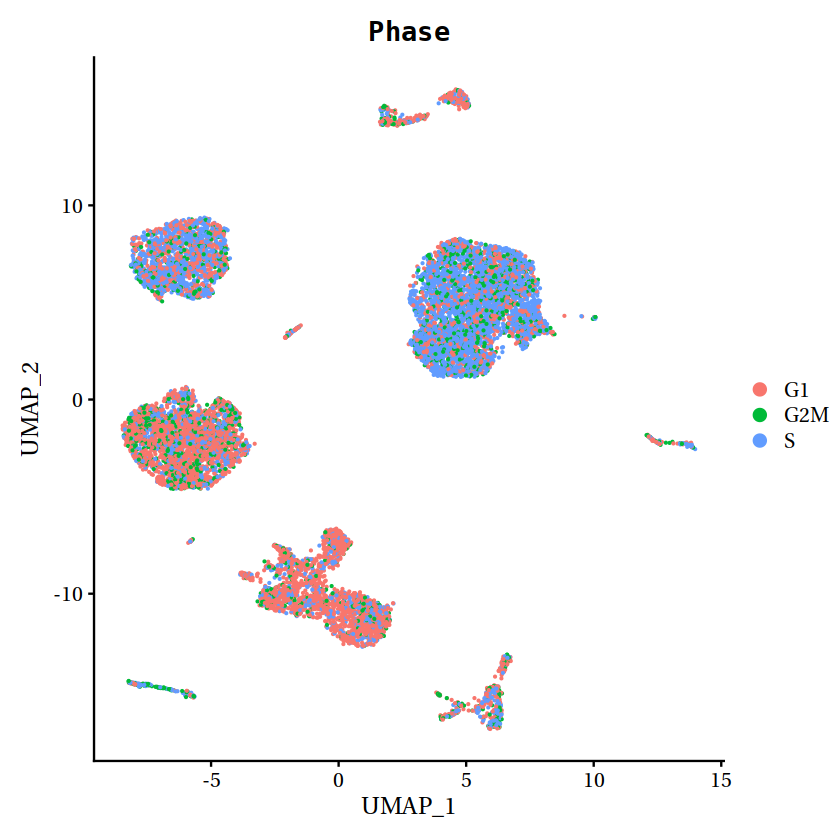

In [45]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

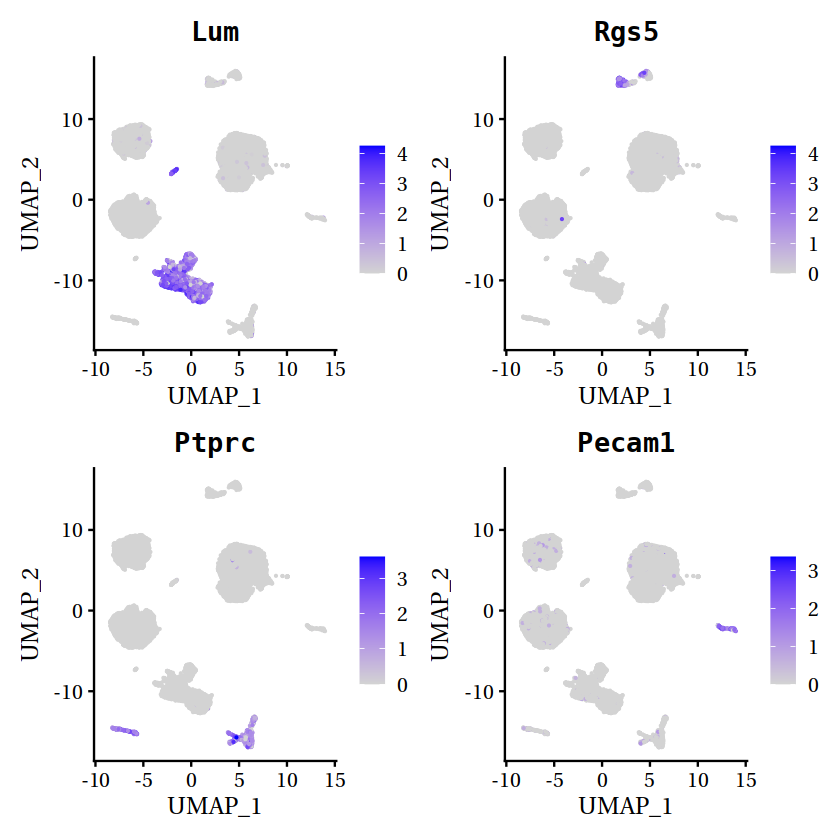

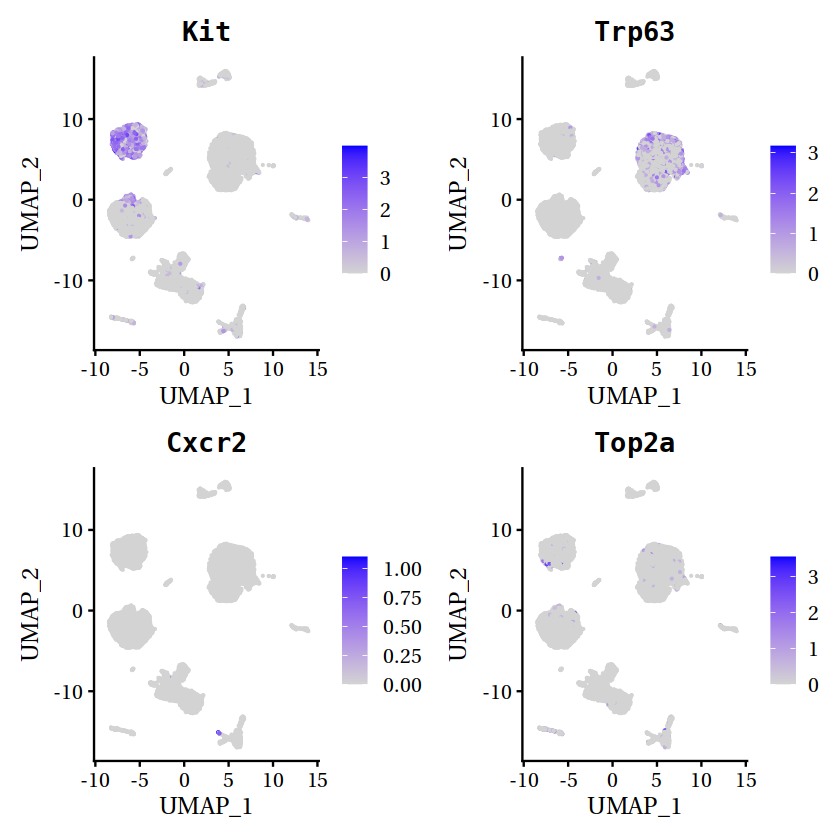

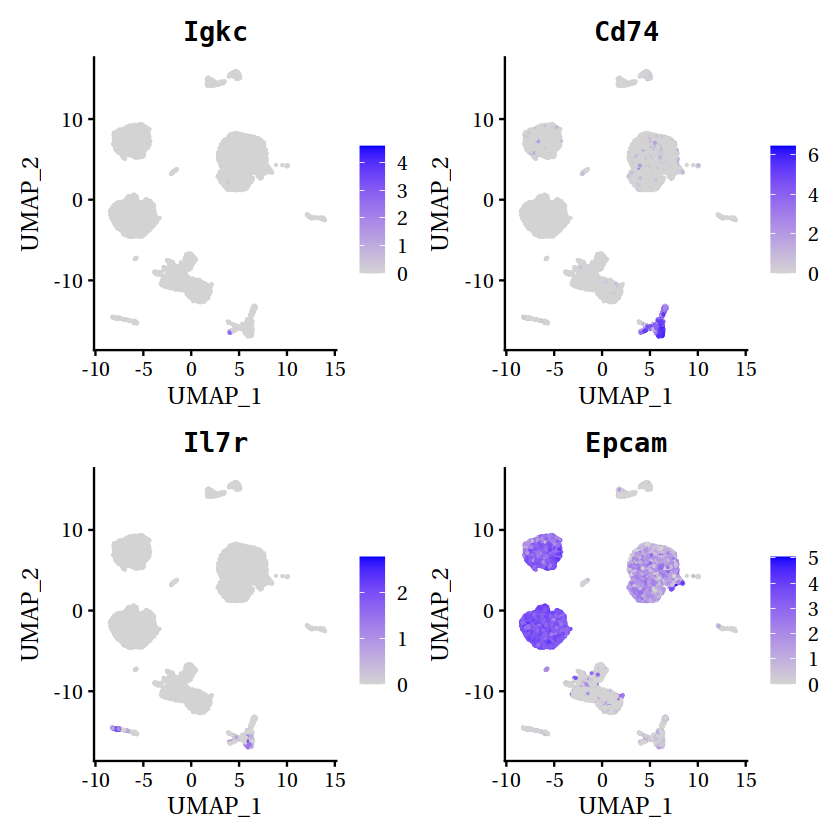

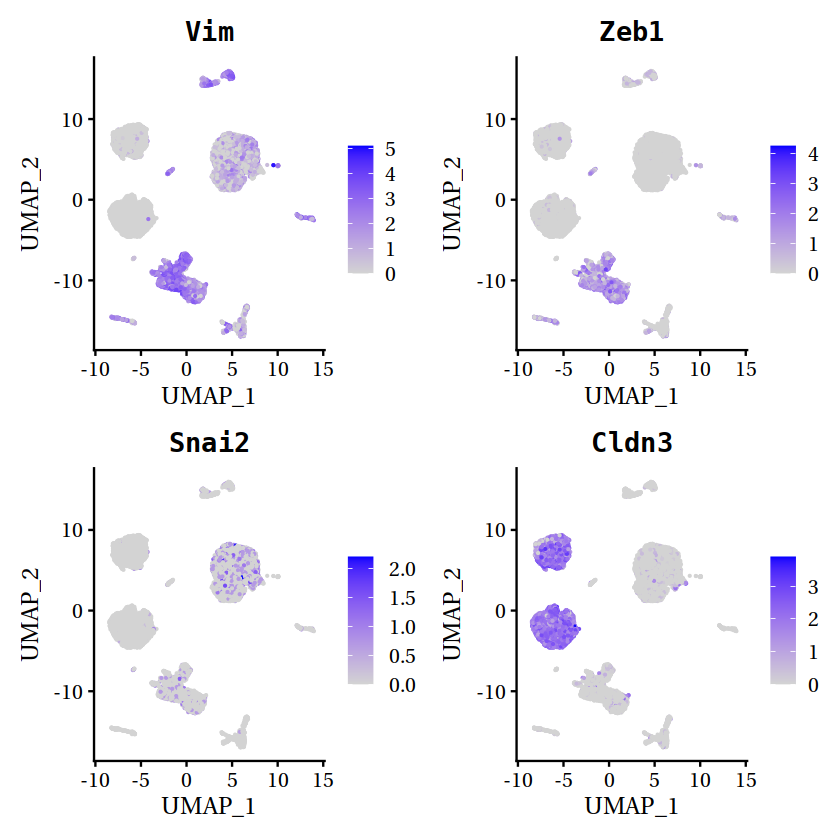

In [46]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

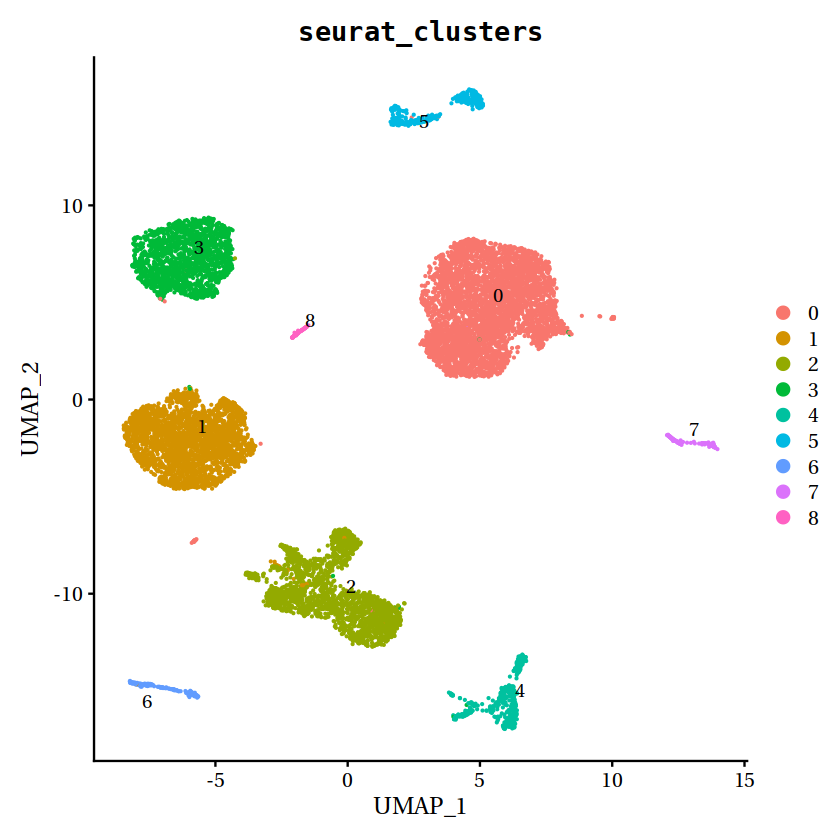

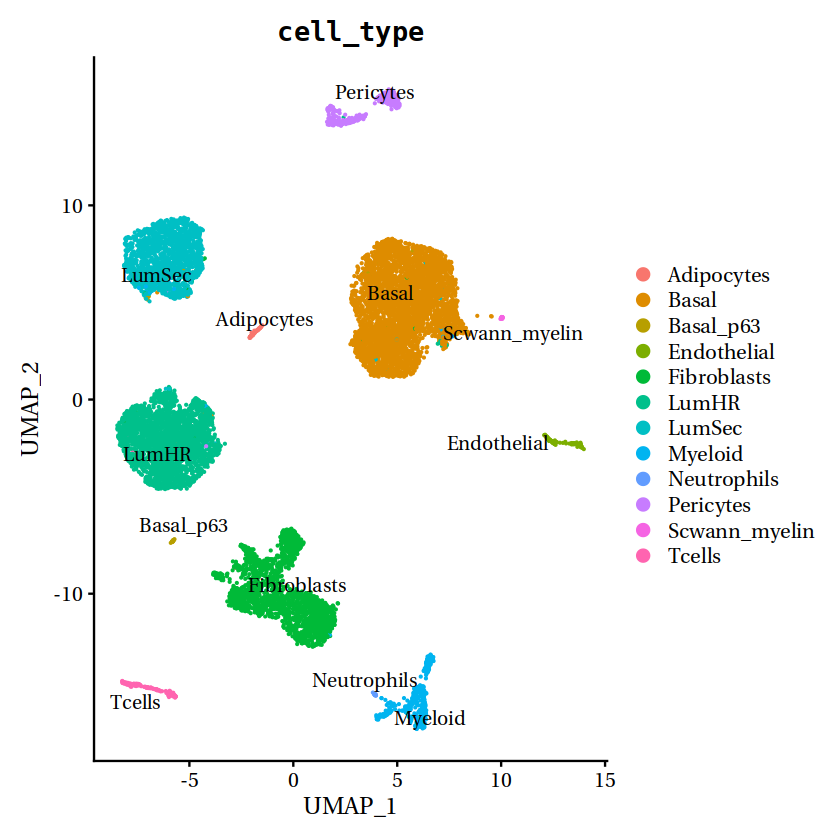

In [47]:
DimPlot(obj, group.by = "seurat_clusters", label = T, repel = T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)

In [48]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Basal", 
                            `1` = "LumHR", 
                            `2` = "Fibroblasts", 
                            `3` = "LumSec",
                            `4` = "Myeloid",
                            `5` = "Pericytes",
                            `6` = "Tcells", 
                            `7` = "Endothelial", 
                            `8` = "Adipocytes")
obj$cell_type <- obj@active.ident

In [49]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Epithelial", 
                            `2` = "Stromal", 
                            `3` = "Epithelial",
                            `4` = "Immune",
                            `5` = "Stromal",
                            `6` = "Immune", 
                            `7` = "Stromal", 
                            `8` = "Stromal")
obj$cell_type_group <- obj@active.ident

In [51]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "wildtype", 
                            `nMFP_12` = "wildtype", 
                            `nMFP_13` = "wildtype",
                            `nMFP_14` = "wildtype",
                            `nMFP_15` = "wildtype",
                            `pMFP_11` = "mutant", 
                            `pMFP_12` = "mutant", 
                            `pMFP_13` = "mutant",
                            `pMFP_14` = "mutant",
                            `pMFP_15` = "mutant")
obj$genotype <- obj@active.ident

In [52]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "normal", 
                            `nMFP_12` = "normal", 
                            `nMFP_13` = "normal",
                            `nMFP_14` = "normal",
                            `nMFP_15` = "normal",
                            `pMFP_11` = "mutant", 
                            `pMFP_12` = "mutant", 
                            `pMFP_13` = "mutant",
                            `pMFP_14` = "mutant",
                            `pMFP_15` = "mutant")
obj$condition_metastatic_burden <- obj@active.ident

In [53]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "normal", 
                            `nMFP_12` = "normal", 
                            `nMFP_13` = "normal",
                            `nMFP_14` = "normal",
                            `nMFP_15` = "normal",
                            `pMFP_11` = "mutant", 
                            `pMFP_12` = "mutant", 
                            `pMFP_13` = "mutant",
                            `pMFP_14` = "mutant",
                            `pMFP_15` = "mutant")
obj$condition_tumor_size_mm <- obj@active.ident

In [54]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "normal", 
                            `nMFP_12` = "normal", 
                            `nMFP_13` = "normal",
                            `nMFP_14` = "normal",
                            `nMFP_15` = "normal",
                            `pMFP_11` = "mutant", 
                            `pMFP_12` = "mutant", 
                            `pMFP_13` = "mutant",
                            `pMFP_14` = "mutant",
                            `pMFP_15` = "mutant")
obj$condition <- obj@active.ident

In [55]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "mammary", 
                            `nMFP_12` = "mammary", 
                            `nMFP_13` = "mammary",
                            `nMFP_14` = "mammary",
                            `nMFP_15` = "mammary",
                            `pMFP_11` = "mammary", 
                            `pMFP_12` = "mammary", 
                            `pMFP_13` = "mammary",
                            `pMFP_14` = "mammary",
                            `pMFP_15` = "mammary")
obj$organ <- obj@active.ident

In [56]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "original", 
                            `nMFP_12` = "original", 
                            `nMFP_13` = "original",
                            `nMFP_14` = "original",
                            `nMFP_15` = "original",
                            `pMFP_11` = "original", 
                            `pMFP_12` = "original", 
                            `pMFP_13` = "original",
                            `pMFP_14` = "original",
                            `pMFP_15` = "original")
obj$transplant_status <- obj@active.ident

In [6]:
obj$cellplex <- "5"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [58]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "removed", 
                            `nMFP_12` = "removed", 
                            `nMFP_13` = "removed",
                            `nMFP_14` = "removed",
                            `nMFP_15` = "removed",
                            `pMFP_11` = "removed", 
                            `pMFP_12` = "removed", 
                            `pMFP_13` = "removed",
                            `pMFP_14` = "removed",
                            `pMFP_15` = "removed")
obj$lymph_node_presence <- obj@active.ident

In [59]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_11` = "wildtype_3", 
                            `nMFP_12` = "wildtype_3", 
                            `nMFP_13` = "wildtype_3",
                            `nMFP_14` = "wildtype_3",
                            `nMFP_15` = "wildtype_3",
                            `pMFP_11` = "mutant_3", 
                            `pMFP_12` = "mutant_3", 
                            `pMFP_13` = "mutant_3",
                            `pMFP_14` = "mutant_3",
                            `pMFP_15` = "mutant_3")
obj$mouse <- obj@active.ident

In [60]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [61]:
obj$S.Score <- NULL
obj$G2M.Score <- NULL
obj$SCT_snn_res.0.1 <- NULL

In [63]:
meta <- read.csv("cellplex5.adata.obs.metadata.csv", row.names=1)
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [8]:
saveRDS(obj, "cellplex5_soupX_doubletfinder_cnv_metadata.rds")

In [1]:
obj <- readRDS("cellplex5_soupX_doubletfinder_cnv_metadata.rds")
DimPlot(obj)

ERROR: Error in DimPlot(obj): could not find function "DimPlot"


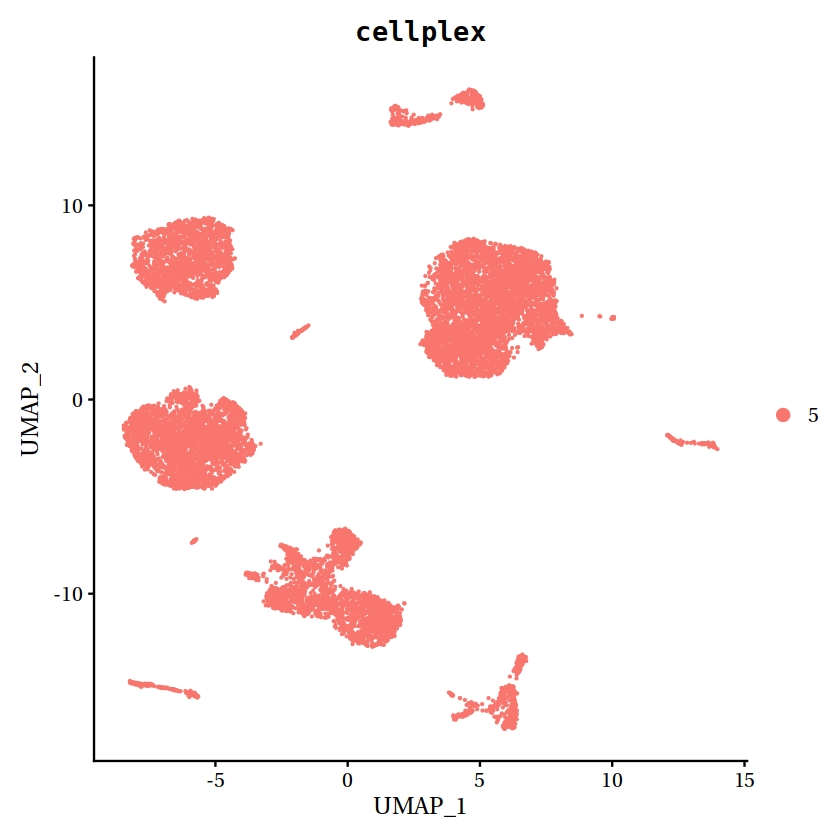

In [9]:
DimPlot(obj, group.by = "cellplex")